In [101]:
ls()

[1] "K"                             "NUM_PARTITION"                
  [3] "SEED"                          "ac"                           
  [5] "all_ct_genes"                  "ann_colors"                   
  [7] "astro_genes_vs_ipc"            "astro_genes_vs_nsc"           
  [9] "astro_genes_vs_oligo"          "astro_module"                 
 [11] "astro_sc"                      "bin_names"                    
 [13] "bin_seq"                       "brks_abs"                     
 [15] "brks_rel"                      "calc_cor_gene_legc_w_md_in_st"
 [17] "cc_data_mat"                   "cc_genes"                     
 [19] "cc_mat_rot"                    "cc_pca_mat"                   
 [21] "cc_sc"                         "cl13_genes"                   
 [23] "cl13_sc"                       "cl1_genes"                    
 [25] "cl1_mc_clvls"                  "cl1_sc"                       
 [27] "cl3_genes"                     "cl3_sc"                       
 [29] "cl6_genes"                     "cl6_mc_clvls"                 
 [31] "cl6_sc"                        "cl7_genes"                    
 [33] "cl7_mc_clvls"                  "cl7_sc"                       
 [35] "clrmp"                         "clrmp_abs"                    
 [37] "clrmp_mod"                     "clrmp_rel"                    
 [39] "col_annot"                     "col_key"                      
 [41] "color_key"                     "cond1"                        
 [43] "cond2"                         "cor_nsc_legc_dyn_genes"       
 [45] "cor_stem_cc_ipc_cyc"           "cor_stem_cc_ipc_cyc_filt"     
 [47] "cor_stem_cc_nsc"               "cor_stem_cc_nsc_filt"         
 [49] "ct_hc_cor_nsc"                 "cust_mc_ord_st"               
 [51] "cust_mc_ord_st2"               "cust_st_ord"                  
 [53] "cust_st_ord2"                  "cycling_scs"                  
 [55] "days"                          "db_path"                      
 [57] "eg"                            "feats"                        
 [59] "feats_all"                     "g_anti_cor_cc"                
 [61] "g_cor_cc"                      "get_genes_specific_to_mcs"    
 [63] "get_mc_cc"                     "glia_mcs"                     
 [65] "goi"                           "hc_cor_nsc"                   
 [67] "inds_plot"                     "ipc_cyc_mcs"                  
 [69] "ipc_cyc_vs_ipc_genes"          "ipc_genes_vs_glia"            
 [71] "ipc_genes_vs_nsc"              "ipc_mcs"                      
 [73] "ipc_module"                    "ipc_sc"                       
 [75] "legc"                          "legc_nsc_dyn_genes_avg_cl"    
 [77] "lupc"                          "m_genes"                      
 [79] "marks_filt"                    "mat"                          
 [81] "mat_ds"                        "mc"                           
 [83] "mc2d"                          "mc_cc"                        
 [85] "mcf"                           "mcmd"                         
 [87] "mct"                           "mgraph"                       
 [89] "nm"                            "nsc_dyn_genes"                
 [91] "nsc_genes"                     "nsc_genes_sc"                 
 [93] "nsc_inds"                      "nsc_ipc_cyc_cells_in_cc_mat"  
 [95] "nsc_legc_gq"                   "nsc_mcs"                      
 [97] "nsc_sc"                        "p_dyn_genes_nsc"              
 [99] "pba"                           "pca_cc"                       
[101] "phase"                         "phase_clvls"                  
[103] "phase_clvls_mod"               "phase_cut"                    
[105] "phase_cut_color"               "phase_pcu"                    
[107] "phase_pcu_rm"                  "phase_pcu_rm_ss"              
[109] "phase_qs"                      "phase_rad"                    
[111] "phase_rev"                     "ra"                           
[113] "rb12"                          "s_genes"                      
[115] "save_

In [6]:
# devtools::load_all('~/src/metacell')
library(metacell)
devtools::load_all('~/src/metacell.flow')
library(pheatmap)
library(ComplexHeatmap)
library(matrixStats)
wd = '/home/feshap/raid/proj/mmcortex'
setwd(wd)
db_path = file.path(wd, 'scdb')
scdb_init(db_path, force_reinit = T)
scdb_flow_init()
SEED = 1337
K = 16
set.seed(SEED)
scfigs_init("figs/")
doMC::registerDoMC(60)
nm = 'pl_cort'


mc = scdb_mc(nm)
mat = scdb_mat(nm)
mct = scdb_mctnetwork(nm)
mcf = scdb_mctnetflow(nm)
mgraph <- scdb_mgraph(nm)
mc2d <- scdb_mc2d(nm)


save_pheatmap_png <- function(x, filename, width=2500, height=2500, res = 150) {
  png(filename, width = width, height = height, res = res)
  grid::grid.newpage()
  grid::grid.draw(x$gtable)
  dev.off()
}

i Loading metacell.flow
Loading required package: grid

ComplexHeatmap version 2.12.1
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))
! pheatmap() has been masked by ComplexHeatmap::pheatmap(). Most of the arguments
   in the original pheatmap() are identically supported in the new function. You 
   can still use the original function by explicitly calling pheatmap::pheatmap().



In [7]:
mcmd = vroom::vroom('./BonevCollab/mcmd_pl_cort.tsv')
col_key <- tibble::deframe(unique(mcmd[,c('cell_type', 'color')]))
color_key = unique(mcmd[,c('cell_type', 'color')])

cust_st_ord = c('Oligodendrocytes','Astrocytes','NSC','IPC_cyc', 'IPC','iCPN/CfuPN', 'iCPN_early','iCPN_late',
                      'CPN_L2-3','CPN_L5_6','iCfuPN','SCPN','CthPN')
cust_mc_ord_st = unlist(lapply(cust_st_ord, function(s) setNames(which(mcmd$cell_type == s)[order(mcmd$mean_day[which(mcmd$cell_type == s)])], 
                                                                  rep(s, length(which(mcmd$cell_type == s)))
                                                                )
                                )
                        )                         
cust_st_ord2 = c('Oligodendrocytes','Astrocytes','NSC','IPC_cyc', 'IPC', 'iCPN_early','iCPN_late',
                      'CPN_L2-3','CPN_L5_6','iCPN/CfuPN','iCfuPN','SCPN','CthPN')
cust_mc_ord_st2 = unlist(lapply(cust_st_ord2, function(s) setNames(which(mcmd$cell_type == s)[order(mcmd$mean_day[which(mcmd$cell_type == s)])], 
                                                                  rep(s, length(which(mcmd$cell_type == s)))
                                                                )
                                )
                        )                         


goi = c('Pou3f1', 'Pou3f2', 'Cux1', 'Cux2', 'Neurod1', 'Neurog2', 'Id4',
         'Eomes', 'Hes1', 'Apoe', 'Sox5', 'Tbr1', 'Foxp2', 'Foxp1', 'Nfia', 'Islr2', 
         'Zbtb20', 'Bcl11b', 'Fezf2', 'Satb2', 'Mef2c', 'Nhlh1', 'Tle4',
        'Rnd2',  'Runx1t1', 'Mapt', 'Mki67', 'Pcna',
        'Fabp7', 'Olig1', 'Ldb2', 'Gadd45g', 'Syt4')
marks_filt = goi

m_genes = c("Mki67","Cenpf","Top2a","Smc4","Ube2c","Ccnb1","Cdk1","Arl6ip1","Ankrd11","Hmmr",
                "Cenpa","Tpx2","Aurka","Kif4", "Kif2c","Bub1b","Ccna2", "Kif23","Kif20a","Sgo2a",
                "Sgo2b","Smc2", "Kif11", "Cdca2","Incenp","Cenpe")
  s_genes = c("Pcna", "Rrm2", "Mcm5", "Mcm6", "Mcm4", "Ung", "Mcm7", "Mcm2","Uhrf1", "Orc6", "Tipin")
cc_genes <- union(m_genes, s_genes)

col_annot = mcmd[,c('metacell', 'cell_type', 'mean_day')]
col_annot = tibble::column_to_rownames(col_annot, 'metacell')

Rows: 1093 Columns: 11
-- Column specification --------------------------------------------------------
Delimiter: "\t"
chr (2): cell_type, color
dbl (9): metacell, E13, E14, E15, E16, E17, E18, mean_day, time_bin

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [8]:
clrmp <- colorRampPalette(c('red', 'orange', 'yellow', 'green', 'blue1', 'blue4', 'purple3'))(1000)

clrmp_abs <- colorRampPalette(c('white', 'orange', 'red', 'purple', 'black'))(1000)
brks_abs <- seq(-16.6,-10, l=1000)

clrmp_rel <- colorRampPalette(c('blue3', 'white','red3'))(1000)
brks_rel <- seq(-3,3, l=1000)

In [9]:
ann_colors = list('cell_type' = tibble::deframe(unique(mcmd[,c('cell_type', 'color')])),
                 'mean_day' = setNames(colorRampPalette(c('red', 'orange', 'yellow', 'green', 'blue', 'purple'))(100),
                                      seq(13,18,l=100)))

In [10]:
legc = log2(1e-05 + mc@e_gc)

In [11]:
st_legc <- as.data.frame(t(tgs_matrix_tapply(legc, mcmd$cell_type, mean)))

In [12]:
feats = scdb_gset('pl_filt_lat')
feats = names(feats@gene_set)
feats = feats[feats %in% rownames(mc@e_gc)]

In [13]:
feats_all <- scdb_gset('pl')

In [14]:
nsc_mcs <- which(mcmd$cell_type == 'NSC')

In [15]:
ipc_cyc_mcs <- which(mcmd$cell_type == 'IPC_cyc')
ipc_mcs <- which(mcmd$cell_type == 'IPC')

In [16]:
nsc_legc_gq <- t(apply(legc[,nsc_mcs], 1, quantile, c(0,0.01,0.05,0.1,0.9, 0.95,0.99,1)))

In [17]:
g_cor_cc <- lapply(c('Pcna', 'Mki67', 'Top2a', 'Mcm5'), function(g) {cor_legc_g <- tgs_cor(t(legc[,nsc_mcs]), as.matrix(legc[g,nsc_mcs]), spearman = F);
                                                        return(rownames(cor_legc_g)[cor_legc_g >= 0.5 & apply(nsc_legc_gq[,c(3,6)], 1, diff) >= 2])})

In [18]:
g_anti_cor_cc <- lapply(c('Pcna', 'Mki67', 'Top2a', 'Mcm5'), function(g) {cor_legc_g <- tgs_cor(t(legc[,nsc_mcs]), as.matrix(legc[g,nsc_mcs]), spearman = F);
                                                        return(rownames(cor_legc_g)[cor_legc_g <= -0.5 & apply(nsc_legc_gq[,c(3,6)], 1, diff) >= 2])})

In [19]:
tfs = readr::read_tsv('~/raid/Mus_musculus_TF.txt')
tfs <- intersect(c('Bcl11b', tfs$Symbol), rownames(legc))
# tfs

Registered S3 methods overwritten by 'readr':
  method                    from 
  as.data.frame.spec_tbl_df vroom
  as_tibble.spec_tbl_df     vroom
  format.col_spec           vroom
  print.col_spec            vroom
  print.collector           vroom
  print.date_names          vroom
  print.locale              vroom
  str.col_spec              vroom

Rows: 1636 Columns: 6
-- Column specification --------------------------------------------------------
Delimiter: "\t"
chr (6): Species, Symbol, Ensembl, Family, Protein, Entrez ID

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [20]:
get_genes_specific_to_mcs <- function(legc, mc_pos = NULL, mc_neg = NULL, cl_vec = NULL) {
    if (!is.null(mc_pos) && is.null(mc_neg)) {
        cl_vec <- ifelse(1:ncol(legc) %in% mc_pos, 1, 0)
    } else if (!is.null(mc_pos) && !is.null(mc_neg)) {
        # if (!(length(intersect(mc_pos, mc_neg)) == 0)) {
        #     stop('mc_pos and mc_neg intersect')
        # }
        legc <- legc[,c(mc_pos, mc_neg)]
        cl_vec <- c(rep(1, length(mc_pos)), rep(0, length(mc_neg)))
    }
    legc_avg <- t(tgs_matrix_tapply(legc, cl_vec, mean))
    if (ncol(legc_avg) == 2) {
        diffs <- matrixStats::rowDiffs(legc_avg)
        rownames(diffs) <- rownames(legc_avg)
        return(diffs[order( diffs[,1], decreasing = T),])
    } else {
        diffs <- t(plyr::laply(1:ncol(legc_avg), function(i) legc_avg[,i] - matrixStats::rowMaxs(legc_avg[,-i]), .parallel = T))
        colnames(diffs) <- colnames(legc_avg)
        return(lapply(1:ncol(diffs), function(i) {
            df <- diffs[which(diffs[,i] > 0.1),]
            return(df[order(df[,i], decreasing = T),])
        }))
    }
}

In [21]:
all_ct_genes <- get_genes_specific_to_mcs(legc, cl_vec = mcmd$cell_type)

In [22]:
names(all_ct_genes) <- sort(unique(mcmd$cell_type))

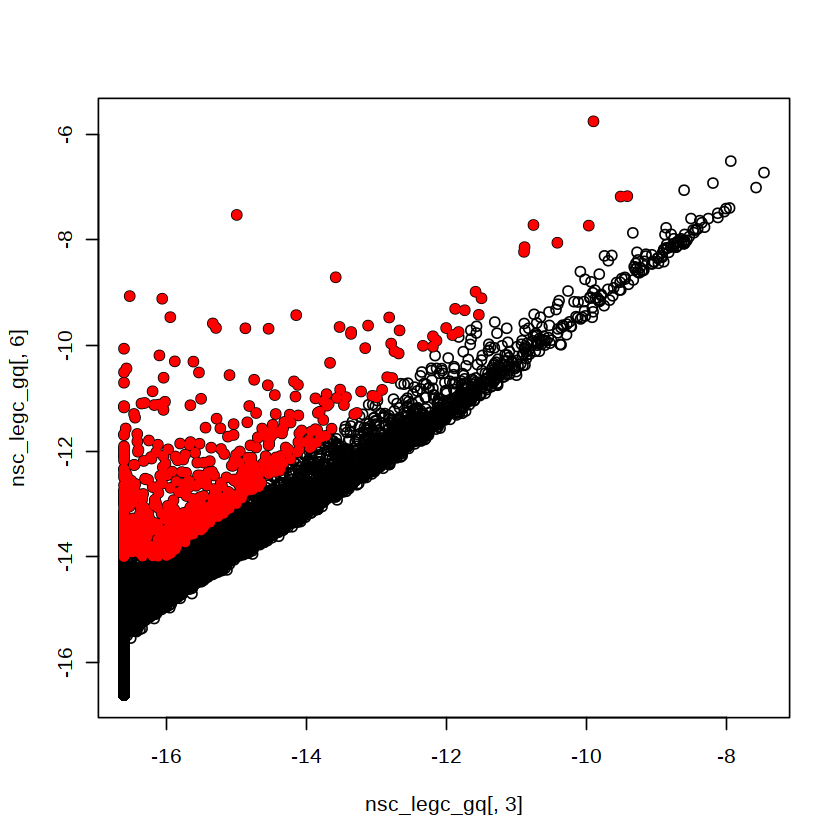

In [23]:
nsc_dyn_genes <- rownames(nsc_legc_gq)[which(apply(nsc_legc_gq[,c(3,6)], 1, diff)>= 2 & nsc_legc_gq[,6] >= -14)]
plot(nsc_legc_gq[,3], nsc_legc_gq[,6])
points(nsc_legc_gq[nsc_dyn_genes,3], nsc_legc_gq[nsc_dyn_genes,6], col ='red', pch = 16)

In [22]:
head(nsc_legc_gq)

,0%,1%,5%,10%,90%,95%,99%,100%
Xkr4,-16.60964,-16.60964,-16.60964,-16.60964,-16.45235,-16.36904,-16.08802,-15.58150
Rp1,-16.60964,-16.60964,-16.60964,-16.60964,-16.37101,-16.15673,-15.66517,-15.41480
Sox17,-16.60964,-16.60964,-16.60964,-16.60964,-16.60964,-16.60964,-16.60964,-16.38239
Mrpl15,-13.94802,-13.76797,-13.19790,-13.07071,-12.54351,-12.49185,-12.31635,-12.20110
Lypla1,-16.60964,-15.87538,-15.34463,-15.17178,-14.30180,-14.19580,-14.00934,-13.93609
Gm37988,-16.60964,-16.60964,-16.60964,-16.60964,-16.60964,-16.39717,-16.29282,-16.14654


In [77]:
calc_cor_gene_legc_w_md_in_st <- function(legc, cell_type, mcmd) {
    mcs_st <- which(mcmd$cell_type == cell_type)
    cor_genes_md <- tgs_cor(t(legc[,mcs_st]), as.matrix(mcmd$mean_day[mcs_st]), spearman=T)
    names(cor_genes_md) <- rownames(legc)
    return(cor_genes_md)
}

In [78]:
cor_nsc_legc_dyn_genes <- tgs_cor(t(legc[nsc_dyn_genes,nsc_mcs]), spearman = T)

In [79]:
hc_cor_nsc <- hclust(dist(cor_nsc_legc_dyn_genes), method = 'ward.D2')

In [80]:
ct_hc_cor_nsc <- cutree(hc_cor_nsc, k = 8)

In [81]:
ct_hc_cor_nsc[c('Sall1', 'Sall3', 'Dmrt3', 'Id1', 'Zbtb20')]

<NA>  Sall3   <NA>    Id1 Zbtb20 
    NA      4     NA      4      4

In [82]:
options(repr.plot.width = 16)
options(repr.plot.height = 8)

In [30]:
glia_mcs <- mcmd$metacell[mcmd$cell_type %in% c('Astrocytes', 'Oligodendrocytes')]

In [34]:
grep('rfx', rownames(mat@mat), ign=T, v=T)

[1] "Rfx8"   "Rfxap"  "Rfx5"   "Rfx6"   "Rfx4"   "Rfxank" "Rfx1"   "Rfx7"  
 [9] "Rfx2"   "Rfx3"

In [35]:
sapply(grep('rfx', rownames(mat@mat), ign=T, v=T), function(u) table(mat@mat[u,]))

$Rfx8

    0     1 
42150    22 

$Rfxap

    0     1     2     3     4     5     6     7     8     9    14 
19496 13203  6113  2233   772   252    65    24    10     3     1 

$Rfx5

    0     1     2     3     4 
39413  2501   226    28     4 

$Rfx6

    0 
42172 

$Rfx4

    0     1     2     3     4     5     6     7     9    10    14 
38835  2379   671   202    54    22     4     1     2     1     1 

$Rfxank

    0     1     2     3     4 
38511  3395   244    20     2 

$Rfx1

    0     1     2     3     5 
37933  3918   298    22     1 

$Rfx7

    0     1     2     3     4     5     6     7     8     9 
22850 11876  4808  1751   602   194    58    19     9     5 

$Rfx2

    0     1     2     3 
41360   762    48     2 

$Rfx3

    0     1     2     3     4     5     6     7 
27379 10793  3050   727   172    38    11     2 


In [91]:
options(repr.plot.width = 16)
options(repr.plot.height = 12)

In [102]:
png('./output/metacell_model/figs/nsc_state_potential_regulators.png', h = 750, w = 1000, res = 100)
par(mfrow = c(3,4), cex.main = 2, mar = c(5,5,2,1), cex.axis = 1.5, cex.lab =2)
uuu <- sapply(c('Sall1', 'Sall3', 'Dmrt3', 'Id1', 'Zbtb20','Sox9','Nfia', 'Nfix', 'Rfx2', 'Rfx3', 'Rfx4'), function(gi) {
        plot(mcmd$mean_day[union(nsc_mcs, glia_mcs)], legc[gi,union(nsc_mcs, glia_mcs)], col = mcmd$color[match(union(nsc_mcs, glia_mcs), mcmd$metacell)], xlab = 'mean day', ylab = 'log2 mRNA fraction',pch = 16, cex = 1.5, main = gi, ylim = c(-16.6, -9))
    if (gi == 'Sall1') {legend('topright', legend = c('NSC', 'Astrocytes', 'Oligodendrocytes'), pch = 16, cex = 1, col = col_key[c('NSC', 'Astrocytes', 'Oligodendrocytes')])}
})
dev.off()

png 
  2

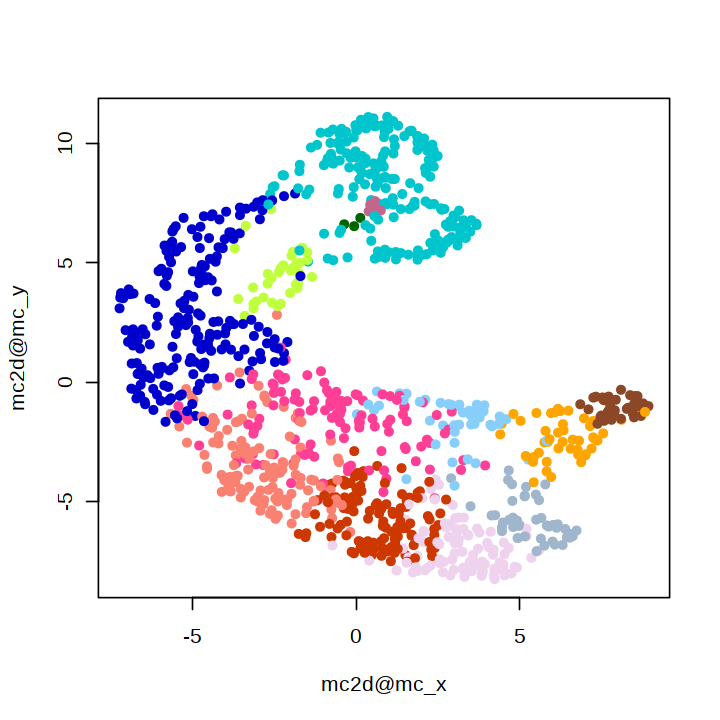

In [59]:
plot(mc2d@mc_x, mc2d@mc_y, col = mcmd$color, pch = 16, cex =1)

In [25]:
rowMaxmins <- function(mat) {setNames(rowMaxs(mat) - rowMins(mat), rownames(mat))}

In [26]:
load('./output/metacell_model/pcurve_nsc_vs_mat_neuro.rda')

In [27]:
ro <- rev(pcu$ord)

In [1682]:
# pheatmap::pheatmap(legc[names(ct_hc_cor_nsc)[order(ct_hc_cor_nsc)],ro[ro %in% nsc_mcs]] - rowMeans(legc[names(ct_hc_cor_nsc)[order(ct_hc_cor_nsc)],nsc_mcs]),
#                    show_colnames = F, 
#                    col = colorRampPalette(c('blue3', 'white', 'red3'))(100),, breaks = seq(-1,1,l=100),
#                    cluster_cols = F, cluster_rows = F, 
#                    annotation_col = ra, annotation_row = ra, annotation_colors = ac)

In [126]:
save(ct_hc_cor_nsc, file = './output/metacell_model/nsc_gene_modules.rda')

In [58]:
ra <- as.data.frame(tibble::column_to_rownames(tibble::enframe(ct_hc_cor_nsc, name = 'gene', value = 'cluster'), 'gene'))

In [59]:
ac <- list(cluster = setNames(chameleon::distinct_colors(8)$name, 1:8))

## Fig S2B

png 
  2

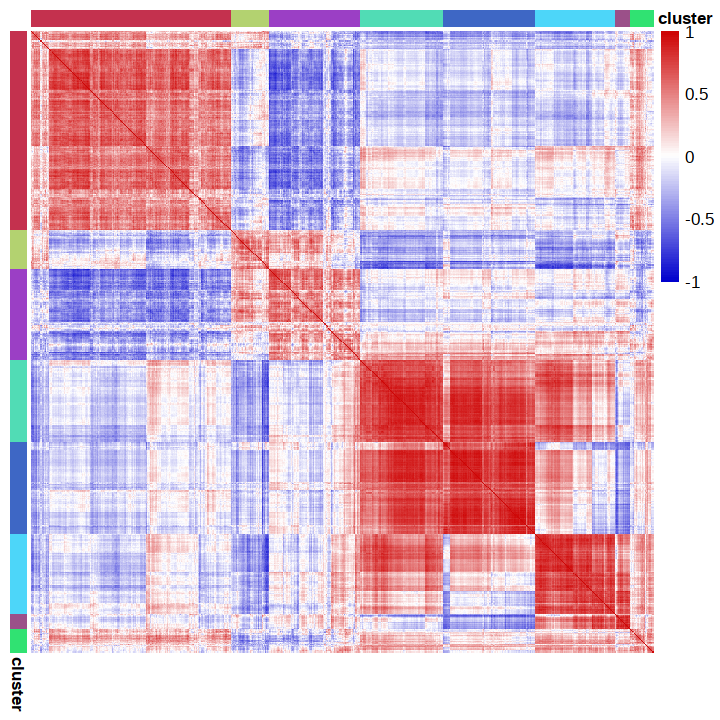

In [35]:
p_cor_dyn_genes_nsc <- pheatmap::pheatmap(cor_nsc_legc_dyn_genes[hc_cor_nsc$order,hc_cor_nsc$order], show_rownames = F, show_colnames = F, annotation_legend = F,
                   col = colorRampPalette(c('blue3', 'white', 'red3'))(100),, breaks = seq(-1,1,l=100),
                   cluster_cols = F, cluster_rows = F, 
                   annotation_col = ra, annotation_row = ra, annotation_colors = ac)
save_pheatmap_png(p_cor_dyn_genes_nsc, './output/metacell_model/figs/nsc_gene_module_analysis/cor_dyn_genes_nsc.png', h = 1600, w = 1600)

In [31]:
options(repr.plot.height = 6)
options(repr.plot.width = 6)

In [42]:
png('./output/metacell_model/figs/nsc_gene_module_analysis/cor_dyn_genes_nsc_legend.png')
yh <- rev(as.numeric(names(ac$cluster)))
plot(rep(1, length(yh)), rev(yh), col = rev(ac$cluster), pch = 16, cex = 5, xlim = c(0.9,1.2), xaxt = 'n', yaxt = 'n', xlab = '', ylab = '', bty = 'n')
text(rep(1.08, length(yh)), rev(yh), labels = paste('Cluster', yh), cex = 3)
dev.off()

png 
  2

In [174]:
ac

$cluster
        1         2         3         4         5         6         7         8 
"#3E67C5" "#9C3FC6" "#9B5188" "#C6314D" "#30E36E" "#4DD6FB" "#51DDB6" "#B3D270"

In [56]:
ipc_cyc_vs_ipc_genes <- get_genes_specific_to_mcs(legc, mc_pos = which(mcmd$cell_type == 'IPC_cyc'), mc_neg = which(mcmd$cell_type == 'IPC'))

In [57]:
ipc_genes_vs_glia <- get_genes_specific_to_mcs(legc, mc_pos = which(mcmd$cell_type %in% c('IPC_cyc', 'IPC')), mc_neg = which(mcmd$cell_type %in% c('Astrocytes', 'Oligodendrocytes')))
ipc_genes_vs_nsc <- get_genes_specific_to_mcs(legc, mc_pos = which(mcmd$cell_type %in% c('IPC_cyc', 'IPC')), mc_neg = which(mcmd$cell_type %in% c('NSC')))

In [58]:
length(sort(names(ipc_genes_vs_glia[ipc_genes_vs_glia >= 2])))
length(sort(names(ipc_genes_vs_nsc[ipc_genes_vs_nsc >= 2])))

[1] 176

[1] 154

In [59]:
ipc_module <- intersect(names(ipc_genes_vs_glia[ipc_genes_vs_glia >= 2]),
                    names(ipc_genes_vs_nsc[ipc_genes_vs_nsc >= 2]))

In [60]:
length(ipc_module)

[1] 113

In [61]:
astro_genes_vs_oligo <- get_genes_specific_to_mcs(legc, mc_pos = which(mcmd$cell_type == 'Astrocytes'), mc_neg = which(mcmd$cell_type %in% c('Oligodendrocytes')))
astro_genes_vs_nsc <- get_genes_specific_to_mcs(legc, mc_pos = which(mcmd$cell_type == 'Astrocytes'), mc_neg = which(mcmd$cell_type %in% c('NSC')))
astro_genes_vs_ipc <- get_genes_specific_to_mcs(legc, mc_pos = which(mcmd$cell_type == 'Astrocytes'), mc_neg = which(mcmd$cell_type %in% c('IPC', 'IPC_cyc')))

In [62]:
astro_module <- intersect(names(astro_genes_vs_oligo[astro_genes_vs_oligo >= 2]),
                      intersect(names(astro_genes_vs_nsc[astro_genes_vs_nsc >= 2]),
                           names(astro_genes_vs_ipc[astro_genes_vs_ipc >= 2])))
length(astro_module)

[1] 66

In [63]:
stem_genes_nsc_fc <- get_genes_specific_to_mcs(legc, mc_pos = which(mcmd$cell_type %in%  c('NSC')), mc_neg = which(mcmd$cell_type %in%  c('Astrocytes', 'IPC')))
stem_genes_ipc_fc <- get_genes_specific_to_mcs(legc, mc_pos = which(mcmd$cell_type %in%  c('IPC_cyc')), mc_neg = which(mcmd$cell_type %in%  c('Astrocytes', 'IPC')))

cond1 <- st_legc[,'NSC'] - st_legc[,'Astrocytes'] >= 1
cond2 <- st_legc[,'NSC'] - st_legc[,'IPC'] >= 1

stem_genes <- rownames(st_legc)[(cond1 & cond2)]
# stem_genes <- rownames(st_legc)[(cond1 & cond2) | (cond3 & cond4)]
sort(stem_genes)

cor_stem_cc_nsc <- tgs_cor(t(legc[stem_genes,which(mcmd$cell_type %in%  c('NSC'))]), 
                       t(legc[c('Top2a', 'Mki67', 'Mcm4', 'Pcna'), which(mcmd$cell_type %in%  c('NSC'))]))
cor_stem_cc_ipc_cyc <- tgs_cor(t(legc[stem_genes,which(mcmd$cell_type %in%  c('IPC_cyc'))]), 
                       t(legc[c('Top2a', 'Mki67', 'Mcm4', 'Pcna'), which(mcmd$cell_type %in%  c('IPC_cyc'))]))

cor_stem_cc_nsc_filt <- cor_stem_cc_nsc[matrixStats::rowMaxs(cor_stem_cc_nsc) < .5,]
cor_stem_cc_ipc_cyc_filt <- cor_stem_cc_ipc_cyc[matrixStats::rowMaxs(cor_stem_cc_ipc_cyc) < .5,]
stem_module <- union(rownames(cor_stem_cc_nsc_filt), rownames(cor_stem_cc_ipc_cyc_filt))
length(stem_module)

sort(stem_module)

[1] "2700038G22Rik" "Adsl"          "Ajuba"         "Akr1b3"       
  [5] "Alyref"        "Amd1"          "Anp32b"        "Arhgap11a"    
  [9] "Asf1b"         "Aspm"          "Atad2"         "Atad5"        
 [13] "Aunip"         "Aurka"         "Aurkb"         "Birc5"        
 [17] "Blm"           "Bora"          "Bub1"          "Bub1b"        
 [21] "C330027C09Rik" "Ccdc18"        "Ccna2"         "Ccnb1"        
 [25] "Ccnb2"         "Ccne1"         "Ccnf"          "Cdc20"        
 [29] "Cdc25c"        "Cdc45"         "Cdc6"          "Cdc7"         
 [33] "Cdca2"         "Cdca3"         "Cdca5"         "Cdca7"        
 [37] "Cdca7l"        "Cdca8"         "Cdk1"          "Cdk2"         
 [41] "Cdon"          "Cdt1"          "Cenpa"         "Cenpe"        
 [45] "Cenpf"         "Cenph"         "Cenpk"         "Cenpl"        
 [49] "Cenpm"         "Cenpn"         "Cenpp"         "Cenpu"        
 [53] "Cenpw"         "Cep55"         "Chaf1a"        "Chaf1b"       
 [57] "Chek1"         "Cit"           "Ckap2"         "Ckap2l"       
 [61] "Cks1b"         "Cks2"          "Clspn"         "Cmtm8"        
 [65] "Col18a1"       "Csrp2"         "Ctps"          "Dbf4"         
 [69] "Dct"           "Dctpp1"        "Ddx39"         "Dek"          
 [73] "Depdc1a"       "Dhfr"          "Dkc1"          "Dlgap5"       
 [77] "Dna2"          "Dnajc9"        "Dnph1"         "Dscc1"        
 [81] "Dtl"           "Dut"           "E2f2"          "E2f3"         
 [85] "E2f7"          "E2f8"          "Ect2"          "Efcab11"      
 [89] "Eif5a"         "Eme1"          "Esco2"         "Exo1"         
 [93] "Exosc2"        "Fbln1"         "Fbxo5"         "Fen1"         
 [97] "Fignl1"        "Fn1"           "Foxm1"         "Frat2"        
[101] "Fzd8"          "Gar1"          "Gas1"          "Gas2l3"       
[105] "Gins1"         "Gins3"         "Gmnn"          "Gpatch4"      
[109] "Grb10"         "H1fx"          "H2afx"         "H2afz"        
[113] "Haspin"        "Haus4"         "Hells"         "Hes1"         
[117] "Hirip3"        "Hist1h1a"      "Hist1h1b"      "Hist1h1d"     
[121] "Hist1h2ab"     "Hist1h2ae"     "Hist1h2ap"     "Hist1h2bj"    
[125] "Hist1h3c"      "Hist1h3e"      "Hist1h4i"      "Hk2"          
[129] "Hmga2"         "Hmgb1"         "Hmgb2"         "Hmgn2"        
[133] "Hmmr"          "Id4"           "Incenp"        "Jph1"         
[137] "Jpt2"          "Kif11"         "Kif15"         "Kif18a"       
[141] "Kif20a"        "Kif20b"        "Kif22"         "Kif23"        
[145] "Kif2c"         "Kif4"          "Kifc1"         "Kmt5a"        
[149] "Knl1"          "Knstrn"        "Kntc1"         "Kpna2"        
[153] "Lbr"           "Lig1"          "Lmnb1"         "Lmnb2"        
[157] "Lockd"         "Lpar1"         "Lpl"           "Lrr1"         
[161] "Lsm2"          "Lsm3"          "Lyar"          "Mad2l1"       
[165] "Mcm10"         "Mcm2"          "Mcm3"          "Mcm5"         
[169] "Mcm6"          "Mcm7"          "Melk"          "Mif"          
[173] "Mis18bp1"      "Mki67"         "Mms22l"        "Mns1"         
[177] "Mpped2"        "Mthfd2"        "Mxd3"          "Mybl2"        
[181] "Napepld"       "Nasp"          "Ncapd2"        "Ncapd3"       
[185] "Ncapg"         "Ncapg2"        "Ncaph"         "Ndc80"        
[189] "Neil3"         "Nop56"         "Nop58"         "Nr4a2"        
[193] "Nrm"           "Nsmce4a"       "Nucks1"        "Nuf2"         
[197] "Nup37"         "Nup85"         "Nusap1"        "Nxt1"         
[201] "Pa2g4"         "Pbk"           "Pcdh19"        "Pclaf"        
[205] "Pcna"          "Peg12"         "Pim1"          "Pimreg"       
[209] "Plk1"          "Plk4"          "Pmf1"          "Pola2"        
[213] "Pold1"         "Pole"          "Ppat"          "Ppil1"        
[217] "Prc1"          "Prim1"         "Psmc3ip"       "Psrc1"        
[221] "Racgap1"       "Rad18"         "Rad51"         "Rad51ap1"     
[225] "Rad54l"        "Ran"           "Ranbp1"        "Rangap1"      
[229] "Rassf

[1] 47

[1] "2700038G22Rik" "Adsl"          "Ajuba"         "Akr1b3"       
 [5] "Amd1"          "Cdon"          "Cenpa"         "Cmtm8"        
 [9] "Csrp2"         "Dct"           "Dkc1"          "Eif5a"        
[13] "Fbln1"         "Fn1"           "Frat2"         "Fzd8"         
[17] "Gar1"          "Gas1"          "Gpatch4"       "Grb10"        
[21] "Hes1"          "Hk2"           "Hmga2"         "Hmgn2"        
[25] "Id4"           "Jph1"          "Kmt5a"         "Lpar1"        
[29] "Lyar"          "Mif"           "Mpped2"        "Napepld"      
[33] "Nop56"         "Nop58"         "Nr4a2"         "Pcdh19"       
[37] "Peg12"         "Pim1"          "Ran"           "Rassf1"       
[41] "Snrpa1"        "Sox3"          "Spata13"       "Srsf2"        
[45] "Srsf7"         "Tcf7l1"        "Wfdc2"

In [64]:
write(astro_module, './output/metacell_model/nsc_gene_modules/astro_module.txt')

write(ipc_module, './output/metacell_model/nsc_gene_modules/ipc_module.txt')

write(stem_module, './output/metacell_model/nsc_gene_modules/stem_module.txt')

In [56]:
# oligo_genes_vs_astro <- get_genes_specific_to_mcs(legc, mc_pos = which(mcmd$cell_type == 'Oligodendrocytes'), mc_neg = which(mcmd$cell_type %in% c('Astrocytes')))
# oligo_genes_vs_nsc <- get_genes_specific_to_mcs(legc, mc_pos = which(mcmd$cell_type == 'Oligodendrocytes'), mc_neg = which(mcmd$cell_type %in% c('NSC')))
# oligo_genes_vs_ipc <- get_genes_specific_to_mcs(legc, mc_pos = which(mcmd$cell_type == 'Oligodendrocytes'), mc_neg = which(mcmd$cell_type %in% c('IPC', 'IPC_cyc')))

# oligo_module <- intersect(names(oligo_genes_vs_astro[oligo_genes_vs_astro >= 2]),
#                       intersect(names(oligo_genes_vs_nsc[oligo_genes_vs_nsc >= 2]),
#                            names(oligo_genes_vs_ipc[oligo_genes_vs_ipc >= 2])))
# length(oligo_module)

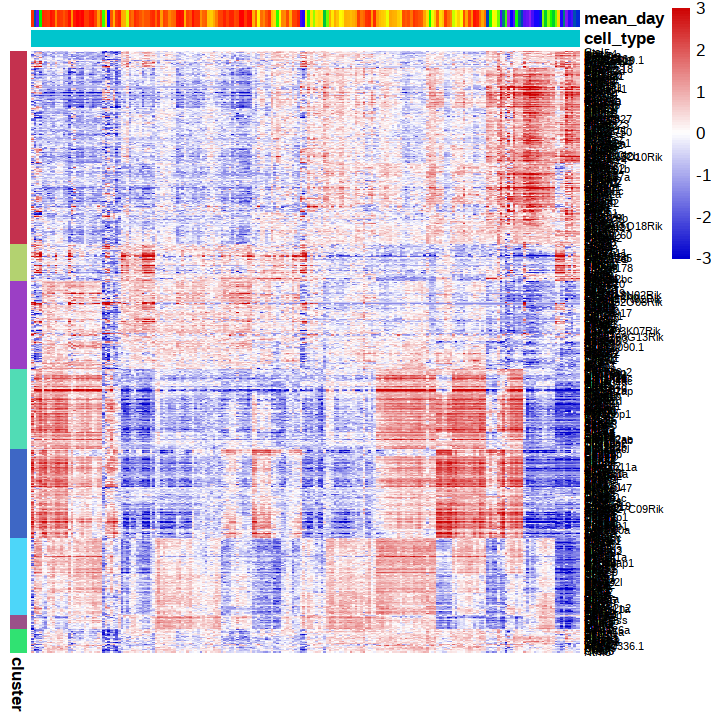

In [60]:
p_dyn_genes_nsc <- pheatmap::pheatmap(legc[names(ct_hc_cor_nsc[hc_cor_nsc$order]),nsc_mcs] - rowMeans(legc[names(ct_hc_cor_nsc[hc_cor_nsc$order]),nsc_mcs]),
                                      fontsize_row = 6, show_rownames = T, show_colnames = F, treeheight_col = 0, annotation_legend = F,
                   col = colorRampPalette(c('blue3', 'white', 'red3'))(100),, breaks = seq(-3,3,l=100),
                   cluster_cols = T, cluster_rows = F, 
                   annotation_col = col_annot, annotation_row = ra, annotation_colors = c(ac, ann_colors))
# save_pheatmap_png(p_dyn_genes_nsc, './output/metacell_model/figs/nsc_gene_module_analysis/all_nsc_dynamic_genes.png', h = 5200, w = 2600)

In [83]:
legc_nsc_dyn_genes_avg_cl <- tgs_matrix_tapply(t(legc[nsc_dyn_genes,nsc_mcs]), ct_hc_cor_nsc, mean)

In [84]:
cl1_mc_clvls <- clrmp[1+999*(legc_nsc_dyn_genes_avg_cl[1,] - min(legc_nsc_dyn_genes_avg_cl[1,]))/(max(legc_nsc_dyn_genes_avg_cl[1,]) - min(legc_nsc_dyn_genes_avg_cl[1,]))]
cl6_mc_clvls <- clrmp[1+999*(legc_nsc_dyn_genes_avg_cl[6,] - min(legc_nsc_dyn_genes_avg_cl[6,]))/(max(legc_nsc_dyn_genes_avg_cl[6,]) - min(legc_nsc_dyn_genes_avg_cl[6,]))]
cl7_mc_clvls <- clrmp[1+999*(legc_nsc_dyn_genes_avg_cl[7,] - min(legc_nsc_dyn_genes_avg_cl[7,]))/(max(legc_nsc_dyn_genes_avg_cl[7,]) - min(legc_nsc_dyn_genes_avg_cl[7,]))]

In [49]:
options(repr.plot.height = 6)
options(repr.plot.width = 18)

## Fig S2C

In [46]:
png('./output/metacell_model/figs/nsc_gene_module_analysis/cc_module_mc_scatter.png', w = 1200, h = 400)
par(mfrow = c(1,3), cex.lab = 3, mar = c(5,5,4,1), cex.axis = 2, cex.main = 3)
plot(legc_nsc_dyn_genes_avg_cl[1,], legc_nsc_dyn_genes_avg_cl[6,], xlab = 'Cluster 1 MC', ylab = 'Cluster 6 MC', main = 'Color = cluster 7', pch = 16, cex = 2.5, col = cl7_mc_clvls)
points(legc_nsc_dyn_genes_avg_cl[1,], legc_nsc_dyn_genes_avg_cl[6,], cex = 2.5)
plot(legc_nsc_dyn_genes_avg_cl[1,], legc_nsc_dyn_genes_avg_cl[7,], xlab = 'Cluster 1 MC', ylab = 'Cluster 7 MC', main = 'Color = cluster 6', pch = 16, cex = 2.5, col = cl6_mc_clvls)
points(legc_nsc_dyn_genes_avg_cl[1,], legc_nsc_dyn_genes_avg_cl[7,], cex = 2.5)
plot(legc_nsc_dyn_genes_avg_cl[6,], legc_nsc_dyn_genes_avg_cl[7,], xlab = 'Cluster 6 MC', ylab = 'Cluster 7 MC',main = 'Color = cluster 1',  pch = 16, cex = 2.5, col = cl1_mc_clvls)
points(legc_nsc_dyn_genes_avg_cl[6,], legc_nsc_dyn_genes_avg_cl[7,],cex = 2.5)
dev.off()

png 
  2

## New mc2d

In [60]:
feats_new <- feats[!(feats %in% names(ct_hc_cor_nsc[ct_hc_cor_nsc %in% c(1,3,6,7)]))]
gs_new <- gset_new_gset(sets = setNames(rep(1, length(feats_new)), feats_new), desc = 'pl_filt_lat and removed all cell cycle-correlated genes')

new_gs_id <- 'pl_filt_lat_cor_cc'
mc_id <- 'pl_cort'
new_mgraph_id <- 'pl_cort_not_cor_cc'

scdb_add_gset(id = new_gs_id, gset = gs_new)

gs <- scdb_gset(new_gs_id)
mc <- scdb_mc(mc_id)

feats_cc <- feats[feats %in% names(ct_hc_cor_nsc[ct_hc_cor_nsc %in% c(1,3,6,7)])]
cc_gs <- gset_new_gset(sets = setNames(rep(1, length(feats_cc)), feats_cc), desc = 'cell-cycle-correlated genes in NSC')

scdb_add_gset(id = 'pl_cort_nsc_cor_cc', gset = cc_gs)

mcell_add_cgraph_from_mat_bknn(mat_id='pl_cort',
                gset_id = 'pl_cort_nsc_cor_cc',
                graph_id='pl_cort_cor_cc',
                K=20,
                dsamp=T)


mcell_mgraph_logistic(mgraph_id=new_mgraph_id, mc_id=mc_id,feats_gset=new_gs_id)

mc = scdb_mc(mc_id)
mg = scdb_mgraph(new_mgraph_id)
mgraph = mg@mgraph

feat_genes = scdb_gset(new_gs_id)
feat_genes = names(feat_genes@gene_set)

library(umap)

uconf <- umap::umap.defaults

uconf$n_neighbors=7
uconf$min_dist = 0.5
uconf$spread = 1
symmetrize = F
umap_mgraph = F

mc_xy = mc2d_comp_graph_coord_umap(mc, feat_genes, mgraph, uconf, umap_mgraph)

cgraph_id <- 'pl_cort'

xy = mc2d_comp_cell_coord(mc_id = mc_id,graph_id = cgraph_id, mgraph = mgraph, cl_xy = mc_xy, symmetrize=symmetrize)
scdb_init('./scdb/', force_reinit = T)

mc2d_id <- new_mgraph_id

mc2d <- tgMC2D(mc_id, mc_xy$mc_x, mc_xy$mc_y, xy$x, xy$y, mgraph)

scdb_add_mc2d(mc2d_id, mc2d)

mcell_mc2d_plot(mc2d_id, colors = mcmd$color)

will downsample the matrix, N= 2653

will build balanced knn graph on 42172 cells and 51 genes, this can be a bit heavy for >20,000 cells

sim graph is missing 263 nodes, out of 42172

got 1436 feat genes for mc graph construction

as(<dgTMatrix>, "dgCMatrix") is deprecated since Matrix 1.5-0; do as(., "CsparseMatrix") instead

Missing coordinates in some cells that are not ourliers or ignored - check this out! (total 6 cells are missing, maybe you used the wrong graph object? first nodes ACTTTCACACTACGGC-1CCTTCAGCATTACTCT-1TCCCAGTTCTAGACCA-1TACCCGTTCTGAGAGG-1TGACCCTGTCCAAGAG-1TTCTTCCTCTCTGAGA-1

initializing scdb to ./scdb/



png 
  2

In [42]:
new_mgraph_id <- 'pl_cort_not_cor_cc'
mc2d_id <- new_mgraph_id
set_param(param = 'mc_plot_device', value = 'pdf', package = 'metacell')
mcell_mc2d_plot(mc2d_id, colors = mcmd$color)

png 
  2

In [79]:
mcell_mc2d_plot_gene(mc2d_id = mc2d_id,gene = 'Pcna')
mcell_mc2d_plot_gene(mc2d_id = mc2d_id,gene = 'Top2a')
mcell_mc2d_plot_gene(mc2d_id = mc2d_id,gene = 'Mki67')
mcell_mc2d_plot_gene(mc2d_id = mc2d_id,gene = 'Ube2c')

mcell_mc2d_plot_gene(mc2d_id = mc2d_id,gene = 'Mcm5')
mcell_mc2d_plot_gene(mc2d_id = mc2d_id,gene = 'Mcm6')

In [25]:
md_clvls <- clrmp[1+round(999*(mcmd$mean_day-13)/(18-13))]

In [37]:
set_param(param = 'mc_plot_device', value = 'pdf', package = 'metacell')

In [166]:
mcell_mc2d_plot(mc2d_id = 'pl_cort_not_cor_cc', colors = md_clvls, fig_fn = './output/metacell_model/figs/pl_cort_mc2d_col_by_mean_day.png')

In [39]:
mcell_mc2d_plot(mc2d_id = 'pl_cort_not_cor_cc', colors = md_clvls, fig_fn = './output/metacell_model/figs/pl_cort_mc2d_col_by_mean_day.pdf')

png 
  2

In [65]:
mc2d <- scdb_mc2d('pl_cort_not_cor_cc')

In [63]:
sc_t <- mat@cell_metadata[names(mc2d@sc_x), 't']

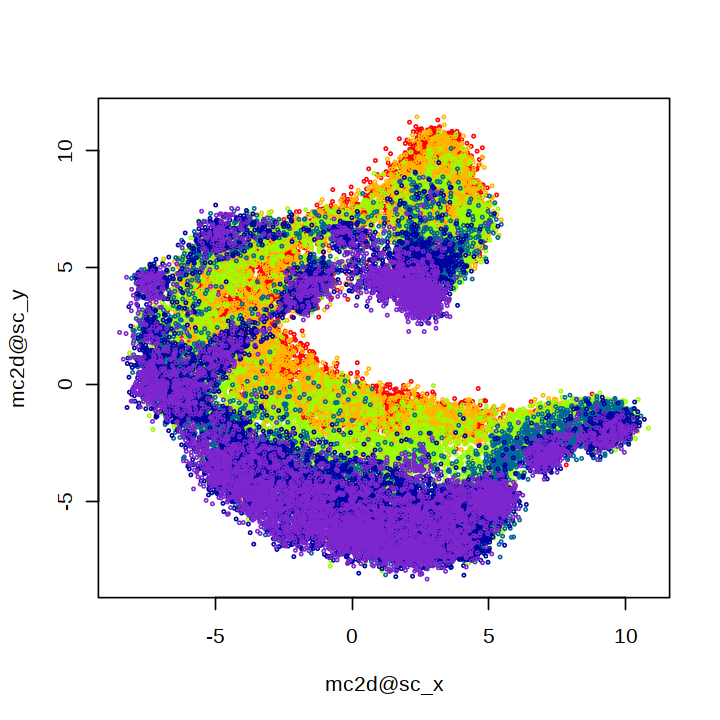

In [66]:
plot(mc2d@sc_x, mc2d@sc_y, col = clrmp[1+round(999*(sc_t-13)/(18-13))], cex = 0.25)

In [40]:
library(Matrix)
scdb_init("scdb/", force_reinit=T)
nm = 'pl_cort'

get_mc_cc = function() {
  ## function from Markus
  mat_id = nm
  mc_id = nm

  tag = nm
  m_0 = 0.0025
  s_0 = 0.001
  m_genes = c("Mki67","Cenpf","Top2a","Smc4","Ube2c","Ccnb1","Cdk1","Arl6ip1","Ankrd11","Hmmr",
                "Cenpa","Tpx2","Aurka","Kif4", "Kif2c","Bub1b","Ccna2", "Kif23","Kif20a","Sgo2a",
                "Sgo2b","Smc2", "Kif11", "Cdca2","Incenp","Cenpe")
  s_genes = c("Pcna", "Rrm2", "Mcm5", "Mcm6", "Mcm4", "Ung", "Mcm7", "Mcm2","Uhrf1", "Orc6", "Tipin")	# Npm1
  m = scdb_mat(mat_id)
  mc = scdb_mc(mc_id)

  s_genes = intersect(rownames(mc@mc_fp), s_genes)
  m_genes = intersect(rownames(mc@mc_fp), m_genes)
  tot  = colSums(m@mat)
  s_tot = colSums(m@mat[s_genes,])
  m_tot = colSums(m@mat[m_genes,])
  s_score = s_tot/tot
  m_score = m_tot/tot

  f = (m_score < m_0 * (1- s_score/s_0))

  mc_cc_tab = table(mc@mc, f[names(mc@mc)])
  mc_cc = 1+floor(99*mc_cc_tab[,2]/rowSums(mc_cc_tab))
  mc_cc = tibble::rownames_to_column(data.frame(mc_cc))

  colnames(mc_cc) = c('mc', 'cc_score')

  mc_cc = dplyr::mutate(mc_cc, mc = as.numeric(mc))
  mc2d = scdb_mc2d('pl_cort_not_cor_cc')

  shades = colorRampPalette(c("white","lightblue", "blue", "purple"))(100)
  png("figs/pl_cort_mc2d_filt_cor_cc.png", w=800, h=800)
  plot(mc2d@sc_x, mc2d@sc_y, pch=19, cex=0.4, col=ifelse(f[names(mc2d@sc_x)], "lightgray","black"))
  points(mc2d@mc_x, mc2d@mc_y, pch=21, cex=2.5, bg=shades[101 - mc_cc$cc_score])
  dev.off()
    
  pdf("figs/pl_cort_mc2d_filt_cor_cc.pdf", w=8, h=8)
  plot(mc2d@sc_x, mc2d@sc_y, pch=19, cex=0.4, col=ifelse(f[names(mc2d@sc_x)], "lightgray","black"))
  points(mc2d@mc_x, mc2d@mc_y, pch=21, cex=2.5, bg=shades[101 - mc_cc$cc_score])
  dev.off()
  return(mc_cc)
}

mc_cc = get_mc_cc()

initializing scdb to scdb/



In [74]:
set.seed(1337)
mat_ds <- scm_downsamp(mat@mat, 3000)

nsc_sc <- intersect(names(mc@mc[mc@mc %in% which(mcmd$cell_type == 'NSC')]), colnames(mat_ds))

In [75]:
nsc_genes <- sort(rownames(all_ct_genes[['NSC']])[all_ct_genes[['NSC']][,'Astrocytes'] <= -1 & all_ct_genes[['NSC']][,'IPC_cyc'] <= -1])

In [85]:
cl1_genes <- names(ct_hc_cor_nsc[ct_hc_cor_nsc == 1])
cl6_genes <- names(ct_hc_cor_nsc[ct_hc_cor_nsc == 6])
cl7_genes <- names(ct_hc_cor_nsc[ct_hc_cor_nsc == 7])
cl3_genes <- names(ct_hc_cor_nsc[ct_hc_cor_nsc == 3])
cl13_genes <- names(ct_hc_cor_nsc[ct_hc_cor_nsc %in% c(1,3)])
cl1_sc <- colSums(mat_ds[cl1_genes,])
cl13_sc <- colSums(mat_ds[cl13_genes,])
cl3_sc <- colSums(mat_ds[cl3_genes,])
# cl6_sc <- colSums(mat_ds[union(cl6_genes, cl3_genes),])
cl6_sc <- colSums(mat_ds[cl6_genes,])
cl7_sc <- colSums(mat_ds[cl7_genes,])
cc_sc <- colSums(mat_ds[c(cl1_genes, cl3_genes, cl6_genes, cl7_genes),])
ipc_sc <- colSums(mat_ds[ipc_module,])
astro_sc <- colSums(mat_ds[astro_module,])
stem_sc <- colSums(mat_ds[stem_module,])
nsc_genes_sc <- colSums(mat_ds[nsc_genes,])
# oligo_sc <- colSums(mat_ds[oligo_module,])

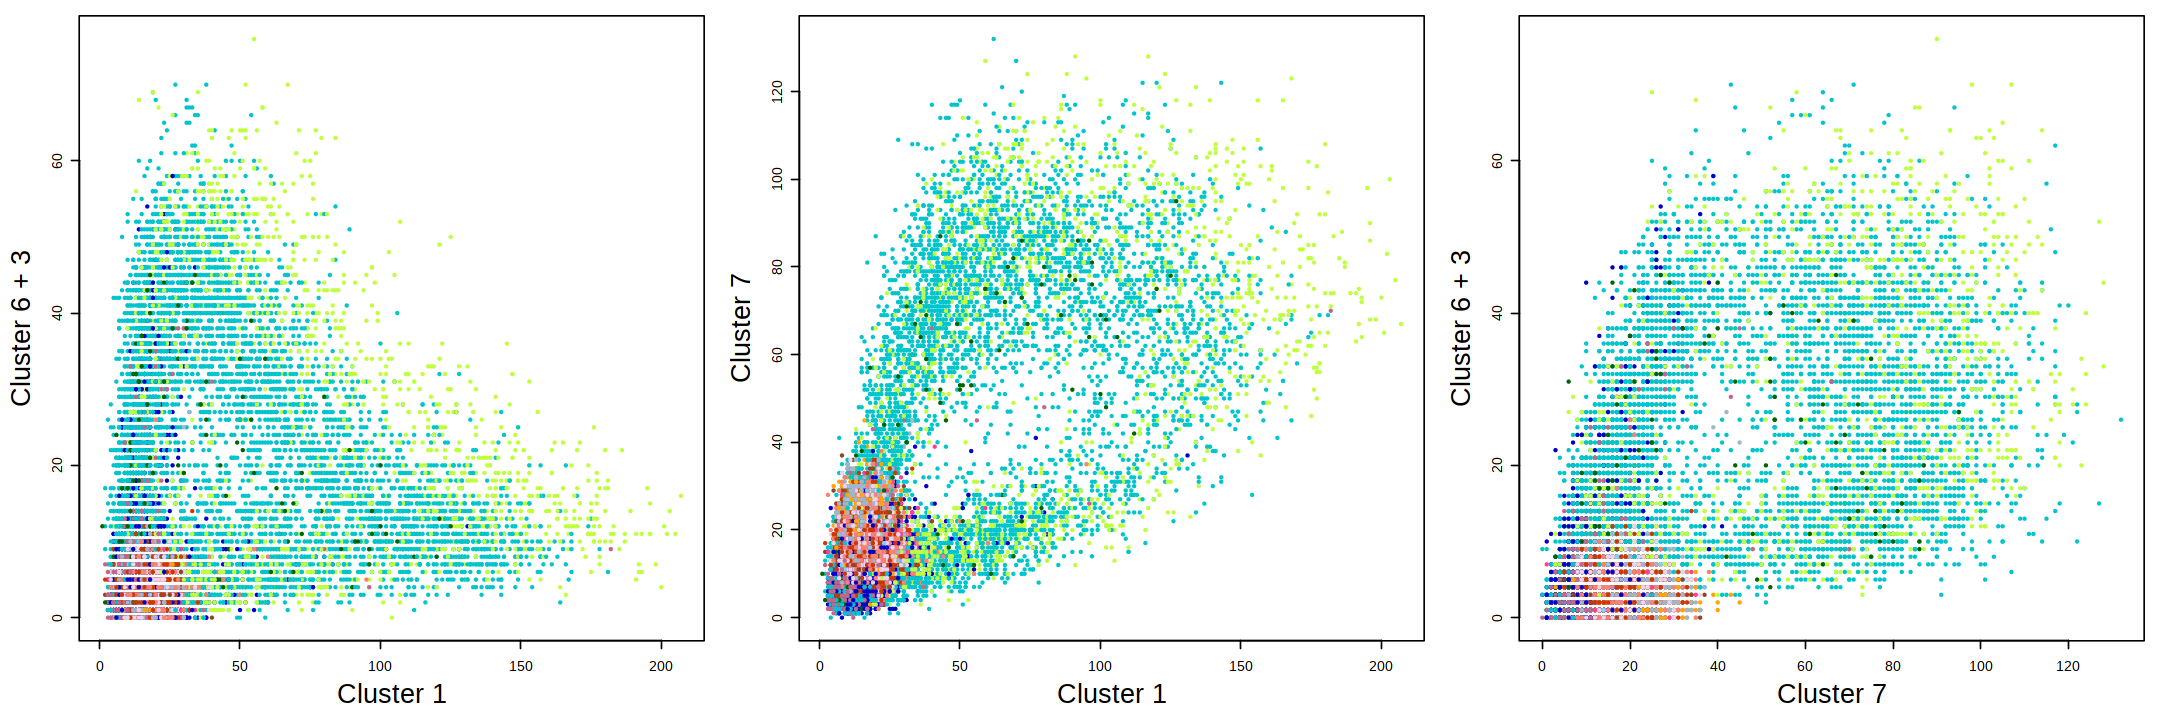

In [86]:
options(repr.plot.width = 18)
options(repr.plot.height = 6)
# png('./output/metacell_model/nsc_gene_modules/figs/pairwise_cell_cycle_clusters_in_scs.png', h = 350, w = 1050)
par(mfrow = c(1,3), cex.lab = 2, mar = c(5,5,1,1))
plot(cl1_sc, cl6_sc, col = color_key$color[match(mcmd$cell_type[mc@mc[names(stem_sc)]], color_key$cell_type)], pch = 16, cex = 0.57, ylab = 'Cluster 6 + 3', xlab = 'Cluster 1')
plot(cl1_sc, cl7_sc, col =color_key$color[match(mcmd$cell_type[mc@mc[names(stem_sc)]], color_key$cell_type)], pch = 16, cex = 0.57, ylab = 'Cluster 7', xlab = 'Cluster 1')
plot(cl7_sc, cl6_sc, col =color_key$color[match(mcmd$cell_type[mc@mc[names(stem_sc)]], color_key$cell_type)], pch = 16, cex = 0.57, ylab = 'Cluster 6 + 3', xlab = 'Cluster 7')
# dev.off()

In [104]:
cc_data_mat <- cbind(cl1_sc - mean(cl1_sc), cl3_sc - mean(cl3_sc), cl6_sc - mean(cl6_sc), cl7_sc - mean(cl7_sc))
pca_cc <- prcomp(x = cc_data_mat)
cc_pca_mat <- pca_cc$x
theta <- 140*pi/180
cc_mat_rot <- cc_pca_mat %*% rbind(c(cos(theta), -sin(theta), 0, 0), c(sin(theta), cos(theta), 0, 0), c(0, 0, 1,  0), c(0, 0, 0, 1))

cycling_scs <- which(cc_sc >= quantile(cc_sc, 0.8))

# phase_rad <- phase_rad_17
phase_rad <- -atan2(cc_mat_rot[,2] - mean(cc_mat_rot[names(cycling_scs),2]), cc_mat_rot[,1] - mean(cc_mat_rot[names(cycling_scs),1]))

phase_clvls <- setNames(clrmp[1+round(999*(phase_rad[rownames(cc_mat_rot)] - min(phase_rad))/(max(phase_rad) - min(phase_rad)))],
                        rownames(cc_mat_rot))

clrmp_mod <- colorRampPalette(c('white', 'orange', 'purple', 'black'))(1000)

phase_clvls_mod <- setNames(clrmp_mod[1+round(999*(phase_rad[rownames(cc_mat_rot)] - min(phase_rad))/(max(phase_rad) - min(phase_rad)))],
                        rownames(cc_mat_rot))

In [105]:
library(princurve)

In [ ]:
nsc_ipc_cyc_cells_in_cc_mat <- intersect(names(mc@mc[mc@mc %in% which(mcmd$cell_type %in% c('NSC', 'IPC_cyc'))]), rownames(cc_mat_rot))

In [ ]:
phase_pcu <- principal_curve(x = cc_mat_rot[nsc_ipc_cyc_cells_in_cc_mat[order(phase_rad[match(nsc_ipc_cyc_cells_in_cc_mat, names(phase_rad))])],1:2], smoother = "periodic_lowess", stretch = 1, approx_points = 100, thresh = 1e-5)

In [ ]:
phase_pcu_rm <- zoo::rollmean(x = phase_pcu$s[,1:2], k = 50)

In [ ]:
phase_pcu_rm_ss <- phase_pcu_rm[sort(sample(x = nrow(phase_pcu_rm), size = round(nrow(phase_pcu_rm)/10), replace = F)),]

In [ ]:
dim(phase_pcu_rm)

In [ ]:
dim(phase_pcu_rm_ss)

In [ ]:
dist_phase_pc_to_pcu <- as.matrix(tgstat::tgs_dist(rbind(cc_mat_rot[,1:2], phase_pcu_rm_ss[,1:2])))

In [ ]:
rownames(dist_phase_pc_to_pcu) <- c(rownames(dist_phase_pc_to_pcu)[1:nrow(cc_mat_rot)], paste0('p', 1:nrow(phase_pcu_rm_ss)))
colnames(dist_phase_pc_to_pcu) <- c(colnames(dist_phase_pc_to_pcu)[1:nrow(cc_mat_rot)], paste0('p', 1:nrow(phase_pcu_rm_ss)))

In [ ]:
knn_phase_pc_to_pcu <- tgstat::tgs_knn(1/dist_phase_pc_to_pcu[(nrow(cc_mat_rot)+1):ncol(dist_phase_pc_to_pcu),1:nrow(cc_mat_rot)], k = 1)

In [ ]:
knn_phase_pc_to_pcu[,2] <- paste0('p', 1:nrow(phase_pcu_rm_ss))[match(knn_phase_pc_to_pcu[,2], rownames(dist_phase_pc_to_pcu))]

In [ ]:
phase <- setNames(as.numeric(gsub('^p', '', knn_phase_pc_to_pcu[,2]))[match(rownames(cc_mat_rot), as.character(knn_phase_pc_to_pcu[,1]))],
                  rownames(cc_mat_rot))

In [ ]:
phase_rev <- max(phase) - phase + 1

In [131]:
NUM_PARTITION <- 13
phase_qs <- seq(1-1e-2,max(phase),l=NUM_PARTITION)

phase_cut <- setNames(cut(phase_rev, phase_qs, labels = paste('bin', 1:(NUM_PARTITION - 1))), names(phase_rev))

In [152]:
save(phase, phase_rev, phase_cut, file = './output/metacell_model/nsc_gene_modules/phase_info.rda')

In [87]:
load('./output/metacell_model/nsc_gene_modules/phase_info.rda')

In [88]:
length(nsc_ipc_cyc_cells_in_cc_mat[order(phase[match(nsc_ipc_cyc_cells_in_cc_mat, names(phase))])])

ERROR: Error in eval(expr, envir, enclos): object 'nsc_ipc_cyc_cells_in_cc_mat' not found


In [89]:
rb12 <- rev(rainbow(12))
phase_cut_color <- setNames(rb12[phase_cut], names(phase_cut))

## Fig S2D

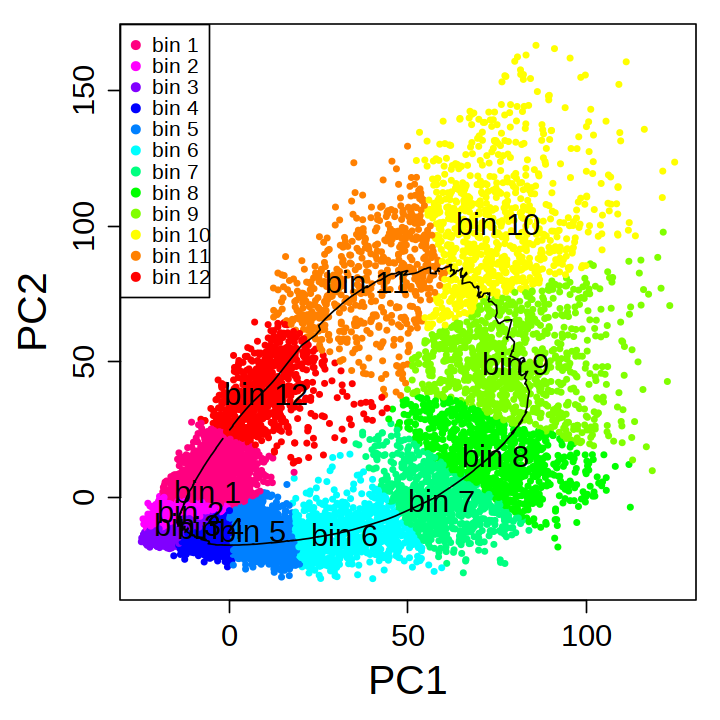

In [89]:
options(repr.plot.width = 6)
options(repr.plot.height = 6)
# png('./output/metacell_model/nsc_gene_modules/figs/pc2_vs_pc1_color_phase_bin.png', h = 600, w = 650, res = 100)
par(cex.axis = 1.5, cex.lab = 2, mar = c(5,5,1,1))
# plot(cc_pca_mat[,1], cc_pca_mat[,2], main = 'PCA no rotation', col = phase_clvls,  pch = 16, cex = 0.37,ylab = 'PC2', xlab = 'PC1')
plot(cc_mat_rot[,1], cc_mat_rot[,2], main = '', 
     col = phase_cut_color,
        pch = 16, cex = 0.67,ylab = 'PC2', xlab = 'PC1')
uuu <- sapply(sort(unique(phase_cut)), function(u) {
    cells <- intersect(names(phase_cut)[phase_cut == u], rownames(cc_mat_rot))
    com_u <- colMeans(cc_mat_rot[cells,1:2])
    text(com_u[[1]], com_u[[2]], labels = u, cex = 1.5)
})
# points(phase_pcu$s[,1], phase_pcu$s[,2])
lines(phase_pcu_rm_ss[,1], phase_pcu_rm_ss[,2])
legend('topleft', legend = sort(unique(phase_cut)), col = unique(phase_cut_color[order(phase_cut)]), pch = 16, cex = 1)
# dev.off()

In [1687]:
# options(repr.plot.width = 6)
# options(repr.plot.height = 6)
# # par(mfrow = c(1,2))
# # plot(cc_pca_mat[,1], cc_pca_mat[,2], main = 'PCA no rotation', col = phase_clvls,  pch = 16, cex = 0.37,ylab = 'PC2', xlab = 'PC1')
# plot(cc_mat_rot[,1], cc_mat_rot[,2], main = 'PCA with rotation', col = phase_clvls, pch = 16, cex = 0.37,ylab = 'PC2', xlab = 'PC1')
# # points(phase_pcu$s[,1], phase_pcu$s[,2])
# lines(phase_pcu_rm_ss[,1], phase_pcu_rm_ss[,2])

In [266]:
plot_color_bar = function(vals, cols, fig_fn=NULL, title="", show_vals_ind=seq(1,1001,round(1001/6)))
{
  if (!is.null(fig_fn)) {
      png(fig_fn, 400, 400)
  }
  plot.new()
  plot.window(xlim=c(0,1000), ylim=c(0, length(cols) + 3))
  rect(7, 1:length(cols), 107, 1:length(cols) + 1, border=NA, col=cols)
  rect(7, 1, 107, length(cols)+1, col=NA, border = 'black')
  text(117, show_vals_ind,cex = 1.5, labels=round(vals[show_vals_ind], 3), pos=4)
  if (!is.null(fig_fn)) {
    dev.off()
  }
}

In [268]:
plot_color_bar(seq(-180,180,l=1001), clrmp, fig_fn = './output/metacell_model/figs/clrmp_phase.png')

png 
  2

In [73]:
phase <- setNames(as.numeric(gsub('^p', '', knn_phase_pc_to_pcu[,2]))[match(rownames(cc_mat_rot), as.character(knn_phase_pc_to_pcu[,1]))],
                  rownames(cc_mat_rot))

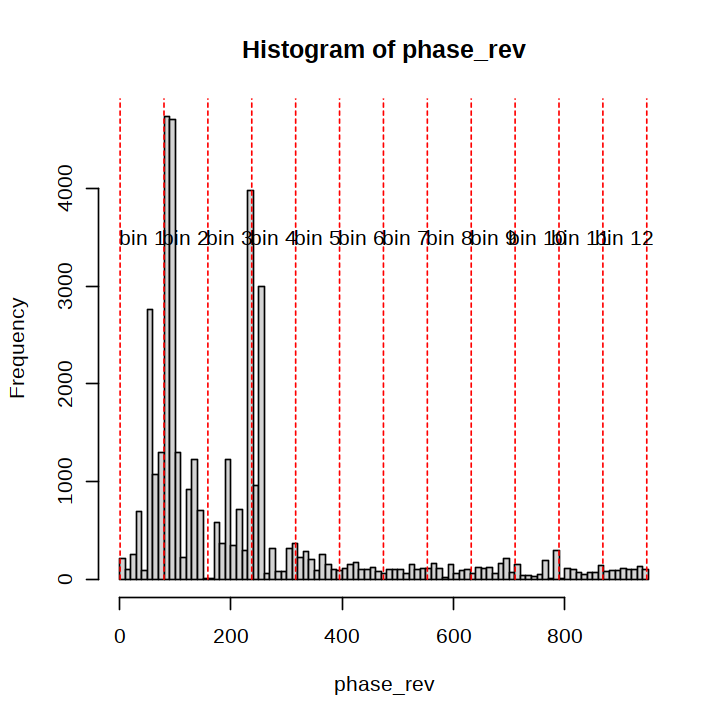

In [74]:
options(repr.plot.width = 6)
options(repr.plot.height = 6)
hist(phase_rev, 100)
uuu <- sapply(phase_qs, function(pq) {lines(rep(pq, 2), c(0, 1e+6), lty = 2, col = 'red')})
text((head(phase_qs, -1) + tail(phase_qs, -1))/2, 3.5e+3, labels = levels(phase_cut))

In [134]:
cc_genes_select <- c('Pcna', 'Mcm7', 'Mki67', 'Top2a')

In [135]:
mat_ds_cc_genes_select_ord_phase <- mat_ds[cc_genes_select, nsc_sc[rev(order(phase[nsc_sc]))]]

K <- 100
mat_ds_cc_genes_select_ord_phase_rm <- t(apply(mat_ds_cc_genes_select_ord_phase, 1, zoo::rollmean, k = K, na.pad = T))

In [93]:
pba <- setNames(as.numeric(phase_cut), names(phase_cut))

pba[pba %in% c(1,4,12)] <- '1_G1'  
pba[pba %in% 5:7] <- '2_S'  
pba[pba %in% 8:9] <- '3_G2'  
pba[pba %in% 10:11] <- '4_M'  
pba[pba %in% 2:3] <- '5_G0'

## Fig 2C

In [107]:
fpba <- factor(pba)

phase_cut_color2 <- factor(setNames(c(colorRampPalette(c('blueviolet', 'orangered'))(4), 'gray')[fpba], names(fpba)))

phase_color_key <- setNames(gplots::col2hex(c(colorRampPalette(c('blueviolet', 'orangered'))(4), 'gray')), levels(fpba))
phase_color_key

1_G1       2_S      3_G2       4_M      5_G0 
"#8A2BE2" "#B13396" "#D83C4B" "#FF4500" "#BEBEBE"

In [116]:
options(repr.plot.width = 8)
options(repr.plot.height = 8)
# png('./output/metacell_model/nsc_gene_modules/figs/pc2_vs_pc1_color_phase.png', h = 1200, w = 1350, res = 100)
pdf('./output/metacell_model/nsc_gene_modules/figs/pc2_vs_pc1_color_phase.pdf', h = 12, w = 13.5)
par(cex.lab = 4, mar = c(8,8,1,1), cex.main = 6, cex.axis = 4)
plot(cc_mat_rot[,1], cc_mat_rot[,2], col = phase_color_key[fpba[rownames(cc_mat_rot)]], pch = 16, cex = 2,ylab = '', xlab = '', xaxt ='n')
llp <- length(phase_color_key)
legend('topleft', col = phase_color_key, legend = gsub('^\\d_', '', names(phase_color_key)), pch = rep(16,llp), cex = rep(4, llp))
axis(1, padj = 1)
title(ylab = 'PC2', line = 4)
title(xlab = 'PC1', line = 6)

dev.off()

png 
  2

## Fig 2E

In [114]:
# png('./output/metacell_model/nsc_gene_modules/figs/nsc_phase_pc1_pc2_scatter_by_day.png', w = 900, h = 700)
pdf('./output/metacell_model/nsc_gene_modules/figs/nsc_phase_pc1_pc2_scatter_by_day.pdf', w = 9, h = 7)
mari <- c(5,.5,3,.5)
par(mfrow = c(2,3), cex.lab = 3, mar = mari, cex.axis = 2, cex.main = 3)
ttt <- lapply(names(nsc_sc_by_day), function(di) {
    if (di %in% c('13', '16')) {
        mari[[2]] <- 6; 
        ylabi = 'PC2'; yaxti = 's'
    } else {mari[[2]] <- 1; ylabi = ''; yaxti = 'n'}
    par(mar = mari)
    plot(cc_mat_rot[nsc_sc_by_day[[di]],1], cc_mat_rot[nsc_sc_by_day[[di]],2], pch = 16, cex = 1.3, 
         col = col_key[['NSC']],
         yaxt = yaxti,
         main = di, 
         xlab = 'PC1', ylab = ylabi, 
         xlim = c(min(cc_mat_rot[,1]), max(cc_mat_rot[,1])), 
        ylim = c(min(cc_mat_rot[,2]), max(cc_mat_rot[,2])))
    sci <- nsc_sc_by_day[[di]]
    text(-10,150,adj = c(0,0.3), labels = paste0(100*round(length(which(fpba[sci] == '5_G0'))/length(sci), 2), '% G0'), cex = 3)
})
dev.off()

png 
  2

## Fig 2D

In [138]:
options(repr.plot.width = 14)
options(repr.plot.height = 14)
# png('./output/metacell_model/nsc_gene_modules/figs/cc_genes_ord_phase_rollmean_clean_new.png', h = 1400, w = 1800, res = 100)
pdf('./output/metacell_model/nsc_gene_modules/figs/cc_genes_ord_phase_rollmean_clean_new.pdf', h = 14, w = 18)
par(mfrow = c(2,2), mar = c(6,7,4,1), cex.lab = 3, cex.axis = 3, cex.main = 5)

bin_borders <- setNames(phase_qs[c(1,2,4,5,8,10,12, 13)], c('G1', 'G1_0', 'G1', 'S', 'G2', 'M', 'G1'))
heights_text <- c(1.5, 2.2, 2.2, 4.2)
ttt <- sapply(1:nrow(mat_ds_cc_genes_select_ord_phase), function(i) {
    plot(sort(phase[nsc_sc]), mat_ds_cc_genes_select_ord_phase[i,], 
         # col = col_key['NSC'], 
         col = 'white', 
         cex = 1, pch = 16, ylim = quantile(mat_ds_cc_genes_select_ord_phase[i,], c(0.05, 0.95)),
        xlab = '', ylab = ''
        # main = rownames(mat_ds_cc_genes_select_ord_phase)[[i]], 
        )
    vvv <- sapply(head(seq_along(bin_borders), -1), function(j) {
        bj <- bin_borders[[j]]
        lines(rep(bj, 2), c(-1,10), lty = 2, lwd = 2)
        nmj <- names(bin_borders)[[j]]
        # text(x = sum(bin_borders[c(j, j+1)])/2, y = heights_text[[i]], labels = nmj, col = phase_color_key[grep(nmj, names(phase_color_key), ign = T)], cex = 3)
    })
    lines(sort(phase[nsc_sc]), mat_ds_cc_genes_select_ord_phase_rm[i,], col = 'black', lwd = 3)
    if (i == 1) {legend('topleft', legend = glue::glue('Rollmean k = {K}'), lwd = 3, col = 'black', cex = 2)}
    title(xlab = 'phase', line = 4)
    title(ylab = 'Downsampled UMIs', line = 4)
})
dev.off()

png 
  2

In [162]:
sort(unique(mat@cell_metadata$day))

[1] "E12" "E13" "E14" "E15" "E16" "E17" "E18"

In [102]:
nsc_sc_by_day <- lapply(tail(sort(unique(mat@cell_metadata$day)),-1), function(di) intersect(nsc_sc, rownames(mat@cell_metadata)[mat@cell_metadata$day == di]))
names(nsc_sc_by_day) <- tail(sort(unique(mat@cell_metadata$day)),-1)
lapply(nsc_sc_by_day, head)

$E13
[1] "AAACCCAAGTCAGGGT-1" "AAACGAACACCCTAAA-1" "AAACGAATCGATCCCT-1"
[4] "AAACGCTAGGCAGTCA-1" "AAACGCTTCAGTCAGT-1" "AAAGAACAGCCTTTGA-1"

$E14
[1] "AAACGCTGTAGAGACC-1" "AAACGCTGTGCCTGCA-1" "AAAGGGCAGAGGACTC-1"
[4] "AACAAAGGTTCTTAGG-1" "AACCAACAGCAGGGAG-1" "AACCAACCATCCAATG-1"

$E15
[1] "AAACCCATCCCGTTGT-1" "AAACGAAGTGGCTGCT-1" "AAACGAATCGCTTGCT-1"
[4] "AAACGCTGTTATTCTC-1" "AAAGTGACACACACGC-1" "AAATGGAGTGTCATTG-1"

$E16
[1] "AAACGAAAGGCTTAGG-1" "AAAGGGCAGGCCTGCT-1" "AACAAAGGTCCAAGAG-1"
[4] "AACAACCTCCTCTCGA-1" "AACAAGACACCTGCAG-1" "AACAGGGAGCACGGAT-1"

$E17
[1] "AAAGGTACACGAGGAT-1" "AAAGGTACATCGGAAG-1" "AAAGTCCTCTGCTAGA-1"
[4] "AACAAAGTCTTGTGCC-1" "AACAACCCACTGAATC-1" "AACACACTCAGCTTGA-1"

$E18
[1] "AAACCCAGTACGGGAT-1" "AACCCAAGTACAACGG-1" "AACGAAAGTACTAGCT-1"
[4] "AAGACAACAGAGTTGG-1" "AAGGAATTCTCGAACA-1" "AAGTACCCAGCAATTC-1"

In [231]:
BW<- 25
K <- 100
nsc_phase_den_by_day <- lapply(nsc_sc_by_day, function(ci) {
    deni <- density(phase[ci], bw = BW)    
})

In [236]:
png('./output/metacell_model/nsc_gene_modules/figs/sc_phase_density_by_day.png', h = 1200, w = 400)
options(repr.plot.width = 10)
options(repr.plot.height = 18)
mari <- c(1,6,1,1)
par(mfrow = c(6,1), mar = mari, cex.lab = 3, cex.axis = 1.5)
heights_text <- 1e-3*c(1.5, 2.2, 2.2, 4.2)
sss <- lapply(seq_along(nsc_phase_den_by_day), function(i) {
    if (i == 6) {xaxti = 's'; mari[[1]] <- 5} else {xaxti = 'n'}
    di <- nsc_phase_den_by_day[[i]]
    par(mar = mari)
    plot(sort(di$x), di$y[order(di$x)], type = 'l', ylab = paste0(names(nsc_sc_by_day)[[i]], ' Density'), xaxt = xaxti, ylim = c(0,2.5e-3), xlab = 'phase')
    vvv <- sapply(head(seq_along(bin_borders), -1), function(j) {
        bj <- bin_borders[[j]]
        lines(rep(bj, 2), c(-1,10), lty = 2, lwd = 2)
        nmj <- names(bin_borders)[[j]]
        text(x = sum(bin_borders[c(j, j+1)])/2, y = heights_text[[2]], labels = nmj, col = phase_color_key[grep(nmj, names(phase_color_key), ign = T)], cex = 3)
    })
})
dev.off()

png 
  2

In [170]:
mat_ds_cc_genes_select_ord_phase_by_day <- lapply(nsc_sc_by_day, function(x) mat_ds[cc_genes_select, x[rev(order(phase[x]))]])
K <- 100
mat_ds_cc_genes_select_ord_phase_rm_by_day <- lapply(mat_ds_cc_genes_select_ord_phase_by_day, function(x) t(apply(x, 1, zoo::rollmean, k = K, na.pad = T)))

In [193]:
options(repr.plot.width = 14)
options(repr.plot.height = 24)
png('./output/metacell_model/nsc_gene_modules/figs/cc_genes_ord_phase_rollmean_by_day.png', h = 2400, w = 1800, res = 100)
mari <- c(2,2,2,2)
par(mfcol = c(6,4), mar = mari, cex.lab = 3, cex.axis = 3, cex.main = 5)
bin_borders <- setNames(phase_qs[c(1,2,4,5,8,10,12, 13)], c('G1', 'G1_0', 'G1', 'S', 'G2', 'M', 'G1'))
heights_text <- c(1.5, 2.2, 2.2, 4.2)
ttt <- sapply(1:nrow(mat_ds_cc_genes_select_ord_phase_rm_by_day[[1]]), function(i) {
            sapply(seq_along(mat_ds_cc_genes_select_ord_phase_rm_by_day), function(j) {
                if (j == 1) {
                    mari[[3]] <- 3
                    maini <- rownames(mat_ds_cc_genes_select_ord_phase_rm_by_day[[j]])[[i]]
                } else {mari[[3]] <- 2; maini <- ''}
                if (i == 1) {
                    mari[[2]] <- 10
                } else {mari[[2]] <- 2}
                par(mar = mari)
                x <- mat_ds_cc_genes_select_ord_phase_rm_by_day[[j]]
                plot(sort(phase[nsc_sc_by_day[[j]]]), x[i,], 
                     # col = col_key['NSC'], 
                     col = 'white', main = maini,
                     cex = 1, pch = 16, ylim = quantile(mat_ds_cc_genes_select_ord_phase[i,], c(0.05, 0.95)),
                    xlab = '', ylab = ''
                    # main = rownames(mat_ds_cc_genes_select_ord_phase)[[i]], 
                    )
                vvv <- sapply(head(seq_along(bin_borders), -1), function(j) {
                    bj <- bin_borders[[j]]
                    lines(rep(bj, 2), c(-1,10), lty = 2, lwd = 2)
                    nmj <- names(bin_borders)[[j]]
                    text(x = sum(bin_borders[c(j, j+1)])/2, y = heights_text[[i]], labels = nmj, col = phase_color_key[grep(nmj, names(phase_color_key), ign = T)], cex = 3)
                })
                lines(sort(phase[nsc_sc_by_day[[j]]]), x[i,], col = 'black', lwd = 3)
                if (i == 1 && j == 1) {legend('topleft', legend = glue::glue('Rollmean k = {K}'), lwd = 3, col = 'black', cex = 2)}
                if (i == 1) {title(ylab = paste0(names(nsc_sc_by_day)[[j]], '\nDownsampled UMIs'), line = 4)}
                title(xlab = 'phase', line = 4)
                
            })
})
dev.off()

png 
  2

In [76]:
ct_by_phase_bin <- as.matrix(t(table(phase_cut, mcmd$cell_type[mc@mc[names(phase_cut)]])))

In [77]:
nsc_sc_by_day <- lapply(13:18, function(di) nsc_sc[nsc_sc %in% rownames(mat@cell_metadata[mat@cell_metadata$day == paste0('E',di),])])

In [78]:
names(nsc_sc_by_day) <- 13:18

## Fig S2F

In [108]:
nsc_sc_by_day_vec <- setNames(unlist(sapply(names(nsc_sc_by_day), function(x) rep(x, length(nsc_sc_by_day[[x]])))), do.call('c', nsc_sc_by_day))

s_genes_sum <- colSums(mat_ds[s_genes,])

m_genes_sum <- colSums(mat_ds[m_genes,])

sm_genes_sum <- colSums(mat_ds[union(m_genes, s_genes),])

options(repr.plot.width = 18)
options(repr.plot.height = 6)


png('./output/metacell_model/nsc_gene_modules/figs/s_m_genes_per_bin_nsc.png', h = 500, w = 1500)
par(mfrow = c(1,3), cex.main = 2, cex.axis = 2, cex.lab = 2, mar = c(6,6,5,1), las = 2)
boxplot(s_genes_sum[names(nsc_sc_by_day_vec)]/length(s_genes) ~ phase_cut[names(nsc_sc_by_day_vec)], main = 'UMIs per S gene per single NSC per bin\nn_{S genes} = 11', ylab = '', xlab = '')
title(ylab = 'UMIs per gene', line = 4)
boxplot(m_genes_sum[names(nsc_sc_by_day_vec)]/length(m_genes) ~ phase_cut[names(nsc_sc_by_day_vec)], main = 'UMIs per M gene per single NSC per bin\nn_{M genes} = 26', ylab = 'UMIs per gene', xlab = '')

boxplot(s_genes_sum[names(nsc_sc_by_day_vec)]/length(s_genes) + m_genes_sum[names(nsc_sc_by_day_vec)]/length(m_genes) ~ phase_cut[names(nsc_sc_by_day_vec)], 
        main = 'UMIs per S+M gene per cell per bin', ylab = 'UMIs per gene', xlab = '')
dev.off()

In [111]:
png('./output/metacell_model/nsc_gene_modules/figs/sum_of_s_m_genes_per_ct.png', h = 400, w = 800)
par(mfrow = c(1,2), las = 2, mar = c(10,5,2,1), cex.axis = 2, cex.lab = 2, cex.main = 2)
boxplot(s_genes_sum ~ mcmd$cell_type[mc@mc[names(s_genes_sum)]], xlab = '', ylab = '', col = col_key[sort(unique(mcmd$cell_type[mc@mc[names(s_genes_sum)]]))], main = 'S genes')
title(ylab = 'Sum of downsampled UMIs', line = 3)
boxplot(m_genes_sum ~ mcmd$cell_type[mc@mc[names(m_genes_sum)]], xlab = '', ylab = '', col = col_key[sort(unique(mcmd$cell_type[mc@mc[names(s_genes_sum)]]))], main = 'M genes')
title(ylab = 'Sum of downsampled UMIs', line = 3)
dev.off()
# boxplot(sm_genes_sum ~ mcmd$cell_type[mc@mc[names(sm_genes_sum)]], xlab = '', col = col_key[sort(unique(mcmd$cell_type[mc@mc[names(s_genes_sum)]]))])

png 
  2

In [112]:
mat_ds_avg_phase <- t(tgs_matrix_tapply(as.matrix(mat_ds[,intersect(names(phase_cut), nsc_sc)]), phase_cut[intersect(names(phase_cut), nsc_sc)], mean))

Warning message in asMethod(object):
"sparse->dense coercion: allocating vector of size 1.7 GiB"


In [113]:
mat_ds_avg_phase_per_day <- lapply(nsc_sc_by_day, function(scdi) t(tgs_matrix_tapply(as.matrix(mat_ds[,intersect(names(phase_cut), scdi)]), phase_cut[intersect(names(phase_cut), scdi)], mean)))

In [114]:
gin <- which(rowMaxs(mat_ds_avg_phase) - rowMins(mat_ds_avg_phase) >= 1)

In [117]:
legc_avg_ct <- t(tgs_matrix_tapply(legc, mcmd$cell_type, mean))

In [121]:
annot_ct_exp <- as.data.frame(apply(legc_avg_ct[,c('Astrocytes', 'IPC')], 1, diff))
colnames(annot_ct_exp) <- 'IPC_vs_Astro_bias'
# ann_col_annot_ct <- list()

In [91]:

ipc_sc_names <- names(mc@mc)[mc@mc %in% which(mcmd$cell_type %in% c('IPC'))]
ipc_cyc_sc_names <- names(mc@mc)[mc@mc %in% which(mcmd$cell_type %in% c('IPC_cyc'))]

astro_sc_names <- names(mc@mc[mc@mc %in% which(mcmd$cell_type == 'Astrocytes')])


In [94]:
sc_data_df <- dplyr::select(mat@cell_metadata[colnames(mat_ds),], day)
sc_data_df$cell_type <- mcmd$cell_type[mc@mc[rownames(sc_data_df)]]
sc_data_df$ipc <- ipc_sc[rownames(sc_data_df)]
sc_data_df$astro <- astro_sc[rownames(sc_data_df)]
sc_data_df$nsc <- nsc_genes_sc[rownames(sc_data_df)]
sc_data_df$stem <- stem_sc[rownames(sc_data_df)]
sc_data_df$cc <- cc_sc[rownames(sc_data_df)]
sc_data_df$phase <- phase[rownames(sc_data_df)]
sc_data_df$phase_rev <- phase_rev[rownames(sc_data_df)]
# sc_data_df$oligo <- oligo_sc[rownames(sc_data_df)]
sc_data_df$phase_cut <- as.numeric(phase_cut[rownames(sc_data_df)])

sc_data_df <- dplyr::mutate(sc_data_df, pba = pba)

In [94]:
tbl_pba_by_ct <- t(table(sc_data_df$cell_type, sc_data_df$pba))
tbl_pba_by_ct_norm <- t(t(tbl_pba_by_ct)/colSums(tbl_pba_by_ct))
tbl_pba_by_ct_norm

      
         Astrocytes     CPN_L2-3     CPN_L5_6        CthPN          IPC
  1_G1 0.1201201201 0.3068716661 0.3845424372 0.3647540984 0.2407303371
  2_S  0.0480480480 0.0207091308 0.0559506875 0.0348360656 0.0226123596
  3_G2 0.0000000000 0.0000000000 0.0000000000 0.0000000000 0.0000000000
  4_M  0.0090090090 0.0000000000 0.0000000000 0.0000000000 0.0001404494
  5_G0 0.8228228228 0.6724192030 0.5595068753 0.6004098361 0.7365168539
      
            IPC_cyc          NSC Oligodendrocytes         SCPN   iCPN/CfuPN
  1_G1 0.3090000000 0.2518291872     0.1728971963 0.4074074074 0.3744122742
  2_S  0.1340000000 0.2928029799     0.1962616822 0.0557899672 0.0128681020
  3_G2 0.2375000000 0.1583078356     0.0841121495 0.0000000000 0.0000000000
  4_M  0.2335000000 0.1174670746     0.0560747664 0.0000000000 0.0000000000
  5_G0 0.0860000000 0.1795929227     0.4906542056 0.5368026254 0.6127196239
      
         iCPN_early    iCPN_late       iCfuPN
  1_G1 0.3390761548 0.3240641711 0.4005602241

In [95]:
rownames(tbl_pba_by_ct_norm) <- gsub('\\d_', '', rownames(tbl_pba_by_ct_norm))

png 
  2

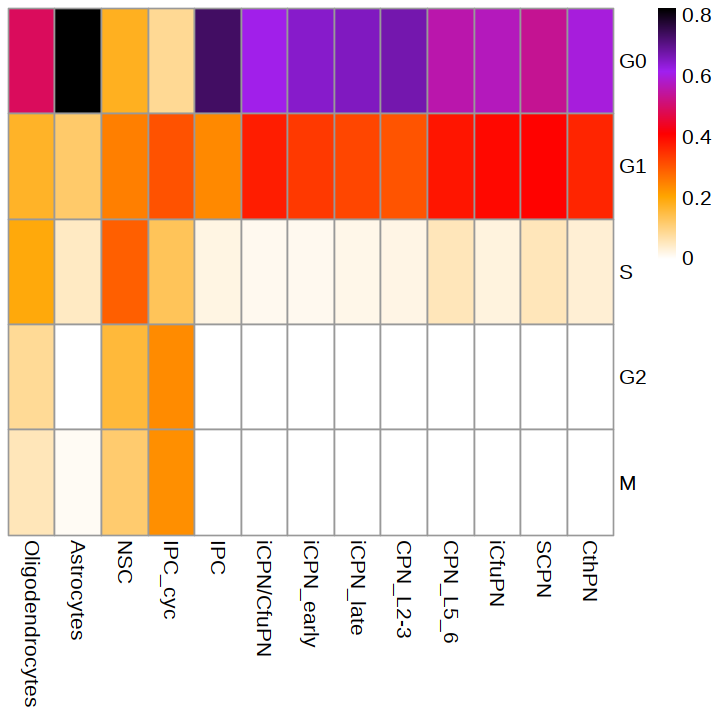

In [131]:
options(repr.plot.width = 6)
options(repr.plot.height = 6)
# annot_here <- tibble::column_to_rownames(color_key, 'cell_type')
# ann_colors_here <- list(color = col_key)
p_pba_by_ct <- pheatmap::pheatmap(tbl_pba_by_ct_norm[,cust_st_ord], cluster_cols = F, annotation_legend = F, col = clrmp_abs, fontsize = 12,
                   # annotation_col = annot_here, annotation_colors = ann_colors, 
                   treeheight_row = 0, treeheight_col = 0)
save_pheatmap_png(p_pba_by_ct, './output/metacell_model/figs/pba_by_ct.png', h = 500, w = 800)

Warning message:
"One or more parsing issues, see `problems()` for details"
Rows: 18 Columns: 1
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (1): Celltype  Marker

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


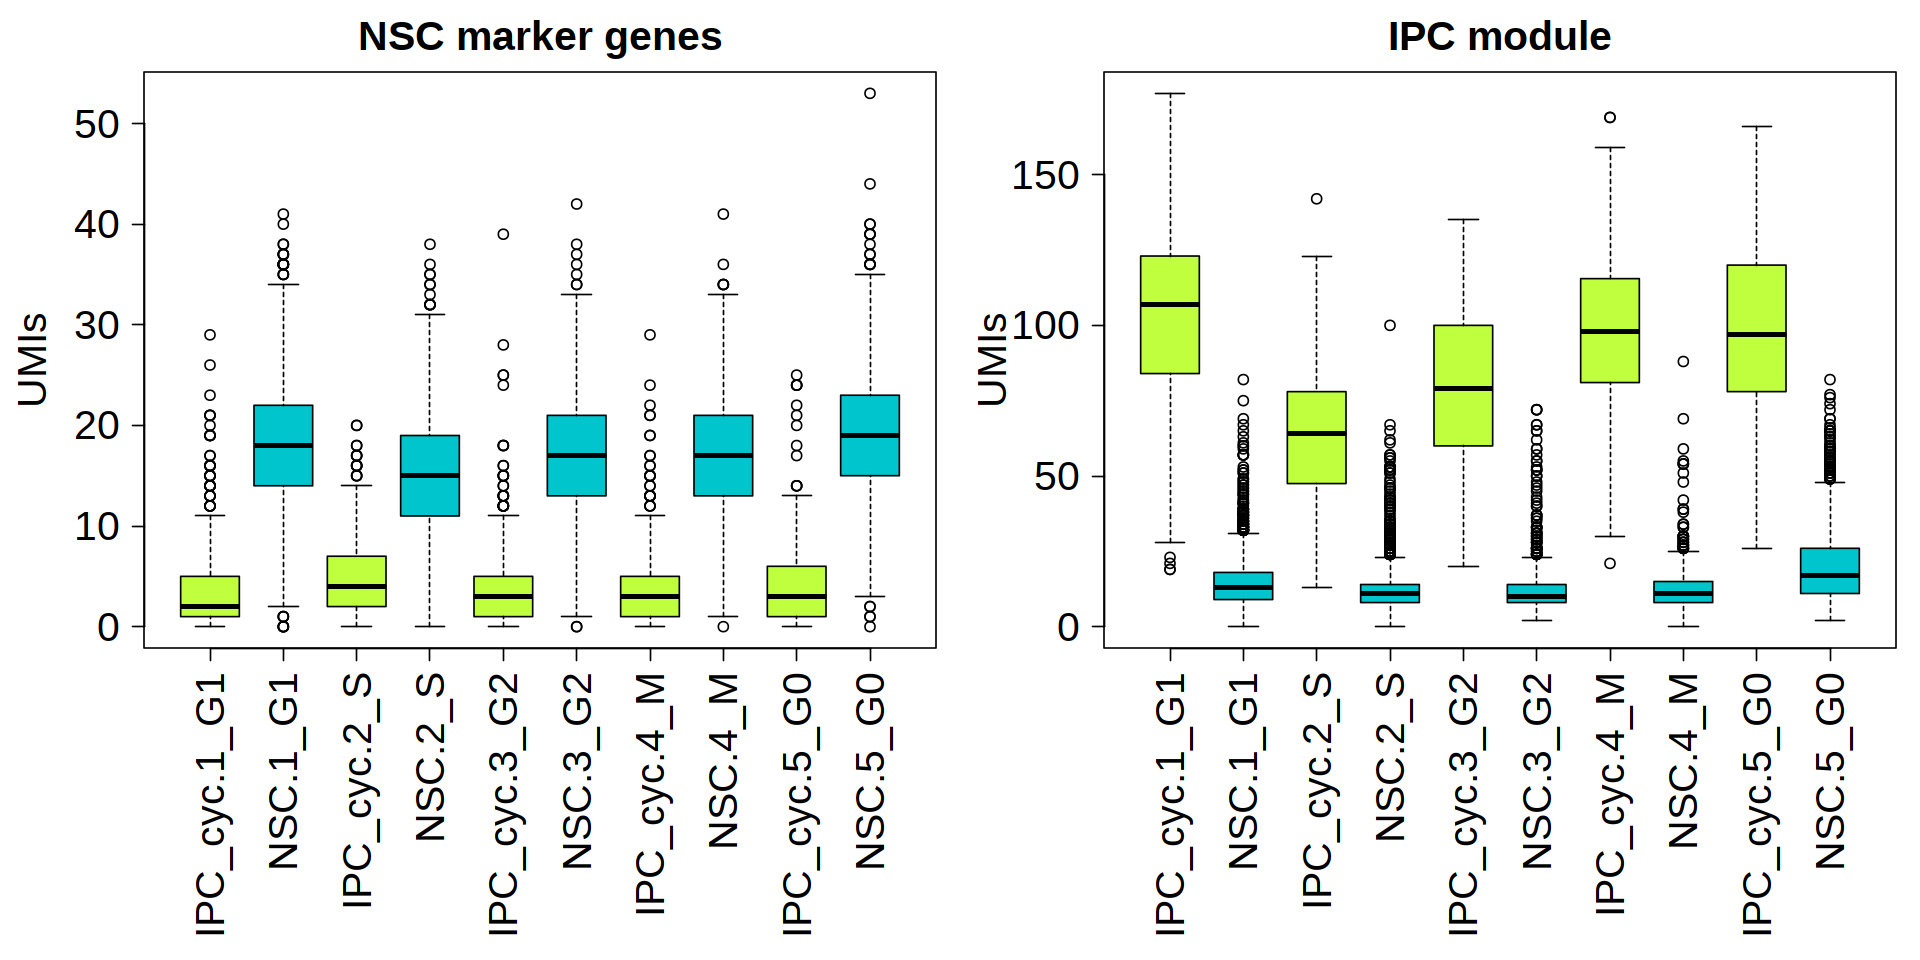

In [84]:
mg_bon_marks <- as.data.frame(t(sapply(apply(readr::read_csv('./BonevCollab//marker_genes.tsv'), 1, 
                                             stringr::str_split, ' '), function(x) c(x[[1]][[1]], x[[1]][[length(x[[1]])]]))))

colnames(mg_bon_marks) <- c('cell_type', 'marks')

mbm_lst <- lapply(1:nrow(mg_bon_marks), function(n) stringr::str_split(mg_bon_marks$marks[[n]], ',')[[1]])
names(mbm_lst) <- mg_bon_marks$cell_type


sc_data_df$nsc <- colSums(mat_ds[mbm_lst[['NSC']],rownames(sc_data_df)])
sc_data_df$color <- col_key[sc_data_df$cell_type]

options(repr.plot.width = 16)
options(repr.plot.height = 8)

# png('./output/metacell_model/figs/ipc_module_vs_nsc_markers_in_nsc_and_ipc_cycs.png', h = 600, w = 800)
par(las = 2, mar = c(13,6,3,1), mfrow = c(1,2), cex.axis = 2, cex.main = 2, cex.lab = 2)
boxplot(nsc ~ ., data = dplyr::select(dplyr::filter(sc_data_df, cell_type %in% c('NSC', 'IPC_cyc')), nsc, cell_type, pba),  col = rep(col_key[c('IPC_cyc', 'NSC')],5), xlab = '' ,main = 'NSC marker genes', ylab = '')
title(ylab = 'UMIs', line = 4)
boxplot(ipc ~ ., data = dplyr::select(dplyr::filter(sc_data_df, cell_type %in% c('NSC', 'IPC_cyc')), ipc, cell_type, pba), col = rep(col_key[c('IPC_cyc', 'NSC')],5), xlab = '',main = 'IPC module', ylab = '')
title(ylab = 'UMIs', line = 4)
# dev.off()

In [85]:
mcs_here <- union(nsc_mcs, which(mcmd$cell_type %in% c('IPC', 'IPC_cyc', 'Astrocytes', 'Oligodendrocytes')))

In [96]:
days <- unique(mat@cell_metadata[nsc_sc,'day'])
days

[1] "E13" "E14" "E15" "E16" "E17" "E18"

## Fig 2B

In [100]:
options(repr.plot.width = 16)
options(repr.plot.height = 16)

mari <- c(5,5,2,2)
BOXWEX <- 0.6
LINE <- 5
png('./output/metacell_model/nsc_gene_modules/figs/gene_modules_in_scs_by_day_boxplots.png', h = 1100, w = 1200)
# pdf('./output/metacell_model/nsc_gene_modules/figs/gene_modules_in_scs_by_day_boxplots.pdf', h = 11, w = 12)
par(mfcol = c(3,3), mar = mari, cex.main = 2, cex.lab = 2, cex.axis = 2, las = 2)
mari[[2]] <- 7
mari[[3]] <- 5
par(mar = mari)
boxplot(ipc_sc[nsc_sc] ~ setNames(mat@cell_metadata[nsc_sc,'day'], nsc_sc), boxwex = BOXWEX, xaxt = 'n',ylim = c(0,quantile(ipc_sc[c(ipc_sc_names, nsc_sc, astro_sc_names)], 0.99, na.rm = T)), ylab = '', main = 'NSCs', xlab = '', col = col_key[['NSC']])
title(ylab = "IPC module (ds UMIs)", line = LINE)
axis(1, at = 1:6, labels = days)
mari[[3]] <- 2
par(mar = mari)
boxplot(astro_sc[nsc_sc] ~ setNames(mat@cell_metadata[nsc_sc,'day'], nsc_sc), boxwex = BOXWEX,xaxt = 'n',ylim = c(0,quantile(astro_sc[c(ipc_sc_names, nsc_sc, astro_sc_names)], .999, na.rm = T)), ylab = '', xlab = '', col = col_key[['NSC']])
title(ylab = "Astro module (ds UMIs)", line = LINE)
axis(1, at = 1:6, labels = days)
boxplot(stem_sc[nsc_sc] ~ setNames(mat@cell_metadata[nsc_sc,'day'], nsc_sc), boxwex = BOXWEX,xaxt = 'n',ylim = c(0,quantile(stem_sc[c(ipc_sc_names, nsc_sc, astro_sc_names)], 0.99, na.rm = T)), ylab = '', xlab = '', col = col_key[['NSC']])
title(ylab = "Stem module (ds UMIs)", line = LINE)
axis(1, at = 1:6, labels = days)

mari[[2]] <- 3
mari[[3]] <- 5
par(mar = mari)
boxplot(ipc_sc[astro_sc_names] ~ setNames(mat@cell_metadata[astro_sc_names,'day'], astro_sc_names), boxwex = BOXWEX, xlim = c(-2.5,3.5), ylim = c(0,quantile(ipc_sc[c(ipc_sc_names, nsc_sc, astro_sc_names)], 0.99, na.rm = T)), ylab = '', main = 'Astrocytes', xlab = '', col = col_key[['Astrocytes']])
axis(1, at = seq(-2,3,1), labels = paste0('E', 13:18))
mari[[3]] <- 2
par(mar = mari)
boxplot(astro_sc[astro_sc_names] ~ setNames(mat@cell_metadata[astro_sc_names,'day'], astro_sc_names), boxwex = BOXWEX, xlim = c(-2.5,3.5),ylim = c(0,quantile(astro_sc[c(ipc_sc_names, nsc_sc, astro_sc_names)], .999, na.rm = T)), ylab = '', xlab = '', col = col_key[['Astrocytes']])
axis(1, at = seq(-2,3,1), labels = paste0('E', 13:18))
boxplot(stem_sc[astro_sc_names] ~ setNames(mat@cell_metadata[astro_sc_names,'day'], astro_sc_names), boxwex = BOXWEX, xlim = c(-2.5,3.5),ylim = c(0,quantile(stem_sc[c(ipc_sc_names, nsc_sc, astro_sc_names)], 0.99, na.rm = T)), ylab = '', xlab = '', col = col_key[['Astrocytes']])
axis(1, at = seq(-2,3,1), labels = paste0('E', 13:18))

mari[[3]] <- 5
mari[[2]] <- 3
par(mar = mari)
boxplot(ipc_sc[ipc_sc_names] ~ setNames(mat@cell_metadata[ipc_sc_names,'day'], ipc_sc_names), boxwex = BOXWEX, ylim = c(0,quantile(ipc_sc[c(ipc_sc_names, nsc_sc, astro_sc_names)], 0.99, na.rm = T)), main = 'IPCs',ylab = '', xlab = '', col = col_key[['IPC']])
mari[[3]] <- 2
par(mar = mari)
boxplot(astro_sc[ipc_sc_names] ~ setNames(mat@cell_metadata[ipc_sc_names,'day'], ipc_sc_names), boxwex = BOXWEX, ylim = c(0,quantile(astro_sc[c(ipc_sc_names, nsc_sc, astro_sc_names)], .999, na.rm = T)), xlab = '', ylab = '',col = col_key[['IPC']])
boxplot(stem_sc[ipc_sc_names] ~ setNames(mat@cell_metadata[ipc_sc_names,'day'], ipc_sc_names), boxwex = BOXWEX, ylim = c(0,quantile(stem_sc[c(ipc_sc_names, nsc_sc, astro_sc_names)], 0.99, na.rm = T)), xlab = '',ylab = '', col = col_key[['IPC']])
# mari[[3]] <- 5
# mari[[2]] <- 2
# par(mar = mari)
# boxplot(ipc_sc[ipc_cyc_sc_names] ~ setNames(mat@cell_metadata[ipc_cyc_sc_names,'day'], ipc_cyc_sc_names), boxwex = BOXWEX, ylim = c(0,quantile(ipc_sc[c(ipc_sc_names, ipc_cyc_sc_names, nsc_sc, astro_sc_names)], 0.99, na.rm = T)), main = 'IPC_cycs', xlab = '', col = col_key[['IPC_cyc']])
# mari[[3]] <- 2
# par(mar = mari)
# boxplot(astro_sc[ipc_cyc_sc_names] ~ setNames(mat@cell_metadata[ipc_cyc_sc_names, 'day'], ipc_cyc_sc_names), boxwex = BOXWEX, ylim = c(0,quantile(astro_sc[c(ipc_sc_names, ipc_cyc_sc_names, nsc_sc, astro_sc_names)], .999, na.rm = T)), xlab = '', col = col_key[['IPC_cyc']])
# boxplot(stem_sc[ipc_cyc_sc_names] ~ setNames(mat@cell_metadata[ipc_cyc_sc_names,'day'], ipc_cyc_sc_names), boxwex = BOXWEX, ylim = c(0,quantile(stem_sc[c(ipc_sc_names, ipc_cyc_sc_names, nsc_sc, astro_sc_names)], 0.99, na.rm = T)), xlab = '', col = col_key[['IPC_cyc']])
dev.off()

png 
  2

## Fig 2A

In [68]:
mcs_here <- union(nsc_mcs, which(mcmd$cell_type %in% c('IPC', 'IPC_cyc', 'Astrocytes', 'Oligodendrocytes')))
legc_mm_nsc <- legc - rowMeans(legc[,nsc_mcs])
mcs_ord <- cust_mc_ord_st[cust_mc_ord_st %in% mcs_here]
mat_ipc_module <- legc_mm_nsc[ipc_module,mcs_ord]
mat_astro_module <- legc_mm_nsc[astro_module,mcs_ord]
mat_stem_module <- legc_mm_nsc[stem_module,mcs_ord] 
hc_mat_ipc <- hclust(dist(mat_ipc_module), method = 'ward.D2')
hc_mat_astro <- hclust(dist(mat_astro_module), method = 'ward.D2')
hc_mat_stem <- hclust(dist(mat_stem_module), method = 'ward.D2')

pltmt_modules <- rbind(mat_ipc_module[hc_mat_ipc$order,], mat_astro_module[hc_mat_astro$order,], mat_stem_module[hc_mat_stem$order,])

In [69]:
marks <- names(scdb_gset('pl_cort_marks_f')@gene_set)
marks

# ipc_genes_not_in_goi <- setdiff(lr[lr %in% ipc_module], lr[lr %in% goi])
ipc_genes_not_in_goi <- setdiff(ipc_module, goi)
lr <- ifelse(rownames(pltmt_modules) %in% setdiff(marks, ipc_genes_not_in_goi), rownames(pltmt_modules), '')


day_mat <- as.matrix(mcmd[,grep('^E\\d\\d', colnames(mcmd))])
rownames(day_mat) <- mcmd$metacell
day_mat_norm <- day_mat/rowSums(day_mat)

col_annot[,colnames(day_mat_norm)] <- day_mat_norm

for (cni in colnames(day_mat_norm)) {
    ann_colors[[cni]] <- setNames(colorRampPalette(c('white', 'black'))(2), c(0,1))
}

p_pltmt_modules <- pheatmap::pheatmap(pltmt_modules, silent = T,
                                      
                                     cluster_cols = F, 
                                     fontsize_row = 14,
                                      
                                     annotation_col = subset(col_annot, select = -mean_day), 
                                           cluster_rows = F, 
                                      
                                     gaps_col = match(unique(names(cust_mc_ord_st)[cust_mc_ord_st %in% mcs_here]), names(cust_mc_ord_st)[cust_mc_ord_st %in% mcs_here]) -1 ,
                                     annotation_legend = F, annotation_colors = ann_colors, 
                                     col = colorRampPalette(c('blue3', 'white', 'red3'))(100), 
                                           breaks = seq(-3,3,l=100), 
                                     treeheight_row = 0, 
                                           show_colnames = F
                                          )

[1] "Pdzrn3"    "Nr2f2"     "Cd24a"     "Frmd4b"    "Lsamp"     "Pou3f1"   
  [7] "Gm42418"   "AY036118"  "Pou3f2"    "Sox11"     "Igfbpl1"   "Unc5d"    
 [13] "Sema3c"    "Cdh4"      "Nr2f1"     "Meis2"     "Sox4"      "Ntm"      
 [19] "Runx1t1"   "Elavl3"    "Stmn4"     "Nefl"      "Syt4"      "Tubb3"    
 [25] "Ncam1"     "Mef2c"     "Gucy1a1"   "Tubb2b"    "Gm17750"   "Frmd4a"   
 [31] "Gria2"     "Myt1l"     "Igsf3"     "Basp1"     "Bhlhe22"   "Flrt3"    
 [37] "Tmsb4x"    "Dab1"      "Ttc28"     "Gpm6a"     "Nrip1"     "Hs6st2"   
 [43] "Satb2"     "Eif1b"     "Rnd2"      "Vat1"      "Ier5l"     "Gm26917"  
 [49] "Cntn2"     "Nts"       "Stmn2"     "Gap43"     "Mapt"      "Ly6h"     
 [55] "Ppp1r14c"  "Opcml"     "Cck"       "Grin2b"    "Meg3"      "Tubb2a"   
 [61] "Ptprd"     "Hs3st4"    "Rtn1"      "Pik3r1"    "Islr2"     "Nfia"     
 [67] "Rprm"      "Map1b"     "Sox5"      "Ina"       "Malat1"    "Ssbp2"    
 [73] "Nfix"      "Hivep2"    "Bcl11b"    "Csrp2"     "Nfib"      "Calb2"    
 [79] "Ier5"      "Rspo3"     "Ubb"       "Tuba1a"    "Ubc"       "Olig1"    
 [85] "Pdgfra"    "Egr1"      "Olig2"     "Ptprz1"    "Fabp7"     "Mt1"      
 [91] "Apoe"      "Id3"       "Aldoc"     "Hist1h1b"  "Hist1h2ap" "Hist1h2ae"
 [97] "Fbxo5"     "Hsp90aa1"  "H1fx"      "Nucks1"    "Phgdh"     "Mfge8"    
[103] "Ptn"       "Mt3"       "Ddah1"     "Sstr2"     "Lrpap1"    "Auts2"    
[109] "Neurod6"   "Neurod2"   "Nrp1"      "Sema6d"    "Epha5"     "Tcf4"     
[115] "Pcp4"      "Dcx"       "Pam"       "Negr1"     "Lars2"     "Mafb"     
[121] "Cxcl12"    "Cdc42ep3"  "Neurod1"   "Nrn1"      "Ube2s"     "Btg2"     
[127] "Chd7"      "Neurog2"   "Eomes"     "Zbtb20"    "Ezr"       "Pantr1"   
[133] "Cdk6"      "Mdk"       "Elavl4"    "Abracl"    "Gadd45g"   "Cdkn1c"   
[139] "Mfng"      "Lhx2"      "Mfap4"     "Igsf8"

[1] 1
[1] 0.9977876 0.9933628 0.9889381 0.9845133 0.9800885 0.9756637
[1] 0.9491150 0.9446903 0.9181416 0.8606195 0.6526549 0.6482301


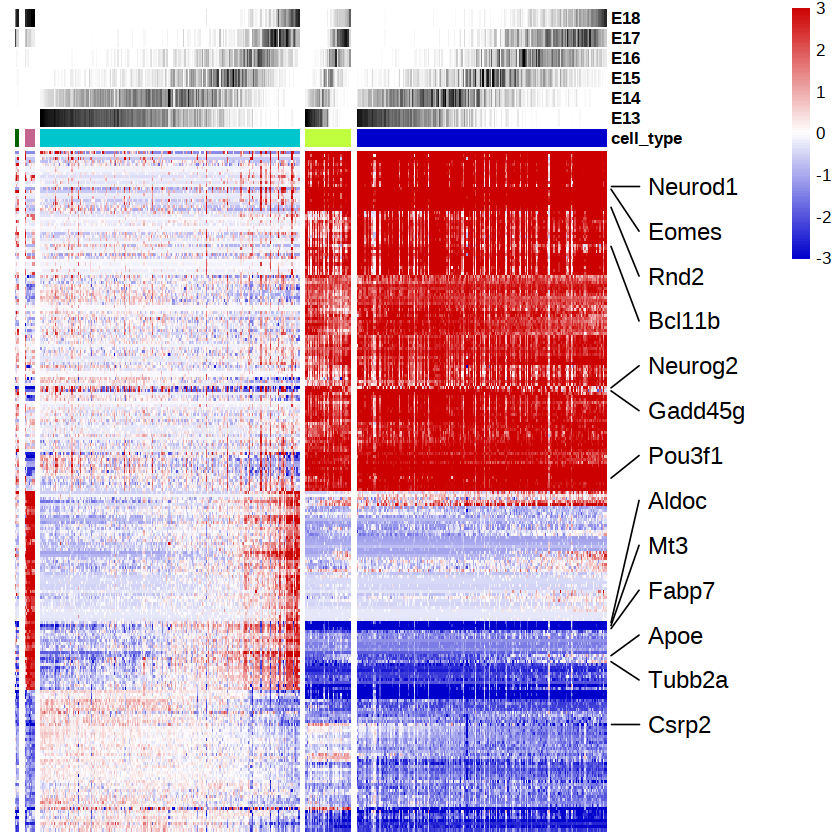

In [70]:
source('./scripts/util.r')

p_pltmt_modules$gtable <- add.flag(pheatmap = p_pltmt_modules, kept.labels = lr, repel.degree = 0)

In [148]:
mcATAC::save_pheatmap(x = p_pltmt_modules,filename =  './output/metacell_model/nsc_gene_modules/figs/nsc_ipc_astro_stem_modules_phm_flag.png', h = 900, w = 850)

In [71]:
my_save_pheatmap <- function (x, filename, dev = png, width = 2000, height = 2000, 
    res = 150)  {
    dev(filename, width = width, height = height)
    grid::grid.newpage()
    grid::grid.draw(x$gtable)
    dev.off()
}

In [72]:
my_save_pheatmap(x = p_pltmt_modules,dev = pdf, filename =  './output/metacell_model/nsc_gene_modules/figs/nsc_ipc_astro_stem_modules_phm_flag.pdf', h = 9, w = 8.5)

png 
  2

In [49]:
mcATAC::save_pheatmap

function (x, filename, dev = png, width = 2000, height = 2000, 
    res = 150) 
{
    dev(filename, width = width, height = height, res = res)
    grid::grid.newpage()
    grid::grid.draw(x$gtable)
    dev.off()
}
<bytecode: 0x55d839bfc398>
<environment: namespace:mcATAC>

In [107]:
nsc_sc_by_day <- lapply(13:18, function(di) nsc_sc[nsc_sc %in% rownames(mat@cell_metadata[mat@cell_metadata$day == paste0('E',di),])])

In [108]:
names(nsc_sc_by_day) <- 13:18

In [109]:
ipc_sc_by_day <- lapply(13:18, function(di) names(mc@mc)[mc@mc %in% which(mcmd$cell_type %in% c('IPC')) & names(mc@mc) %in% rownames(mat@cell_metadata[mat@cell_metadata$day == paste0('E',di),]) & names(mc@mc) %in% colnames(mat_ds)])

In [110]:
names(ipc_sc_by_day) <- 13:18

In [111]:
ipc_cyc_sc_by_day <- lapply(13:18, function(di) names(mc@mc)[mc@mc %in% which(mcmd$cell_type %in% c('IPC_cyc')) & names(mc@mc) %in% rownames(mat@cell_metadata[mat@cell_metadata$day == paste0('E',di),]) & names(mc@mc) %in% colnames(mat_ds)])

In [112]:
names(ipc_cyc_sc_by_day) <- 13:18

In [113]:
sc_by_day <- lapply(13:18, function(di) {y <- rownames(mat@cell_metadata[mat@cell_metadata$day == paste0('E',di),]); return(y[y %in% names(mc@mc)])})

In [114]:
names(sc_by_day) <- 13:18

In [163]:
options(repr.plot.width = 14)
options(repr.plot.height = 7)

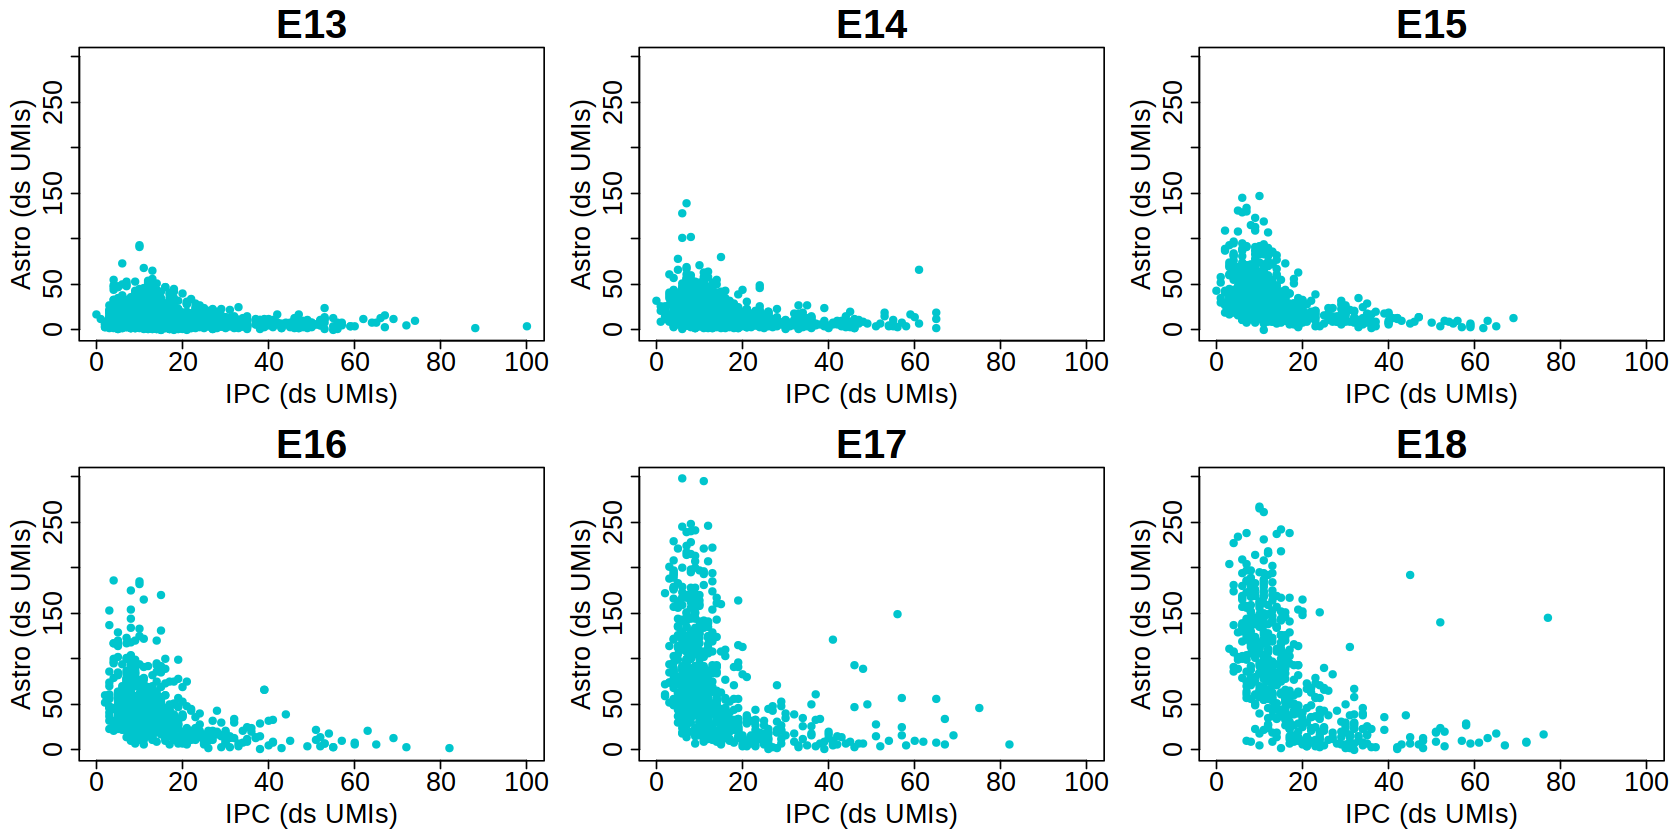

In [165]:
# png('./output//metacell_model/nsc_gene_modules/figs/astro_vs_ipc_in_nsc_by_day_scatter.png', h = 400, w = 800)
mari <- c(5,5,3,1)
par(mfrow = c(2,3), mar = mari, cex.main = 3, cex.lab = 2, cex.axis = 2)
ttt <-lapply(names(nsc_sc_by_day), function(di) {
    cdi <- nsc_sc_by_day[[di]]
    plot(ipc_sc[cdi], astro_sc[cdi], 
         # col = phase_clvls[cdi],
         col = mcmd$color[mc@mc[cdi]], 
         xlab = 'IPC (ds UMIs)', ylab = "Astro (ds UMIs)", main = paste0('E',di),
         pch = 16, cex = 1.25,
         xlim = c(0, quantile(ipc_sc[nsc_sc], 1)),
         ylim  = c(0, quantile(astro_sc[nsc_sc], 1)))
         # xlim = c(0, quantile(ipc_sc[nsc_sc], 0.999)),
         # ylim  = c(0, quantile(astro_sc[nsc_sc], 0.999)))
})
# dev.off()

## Fig S2E

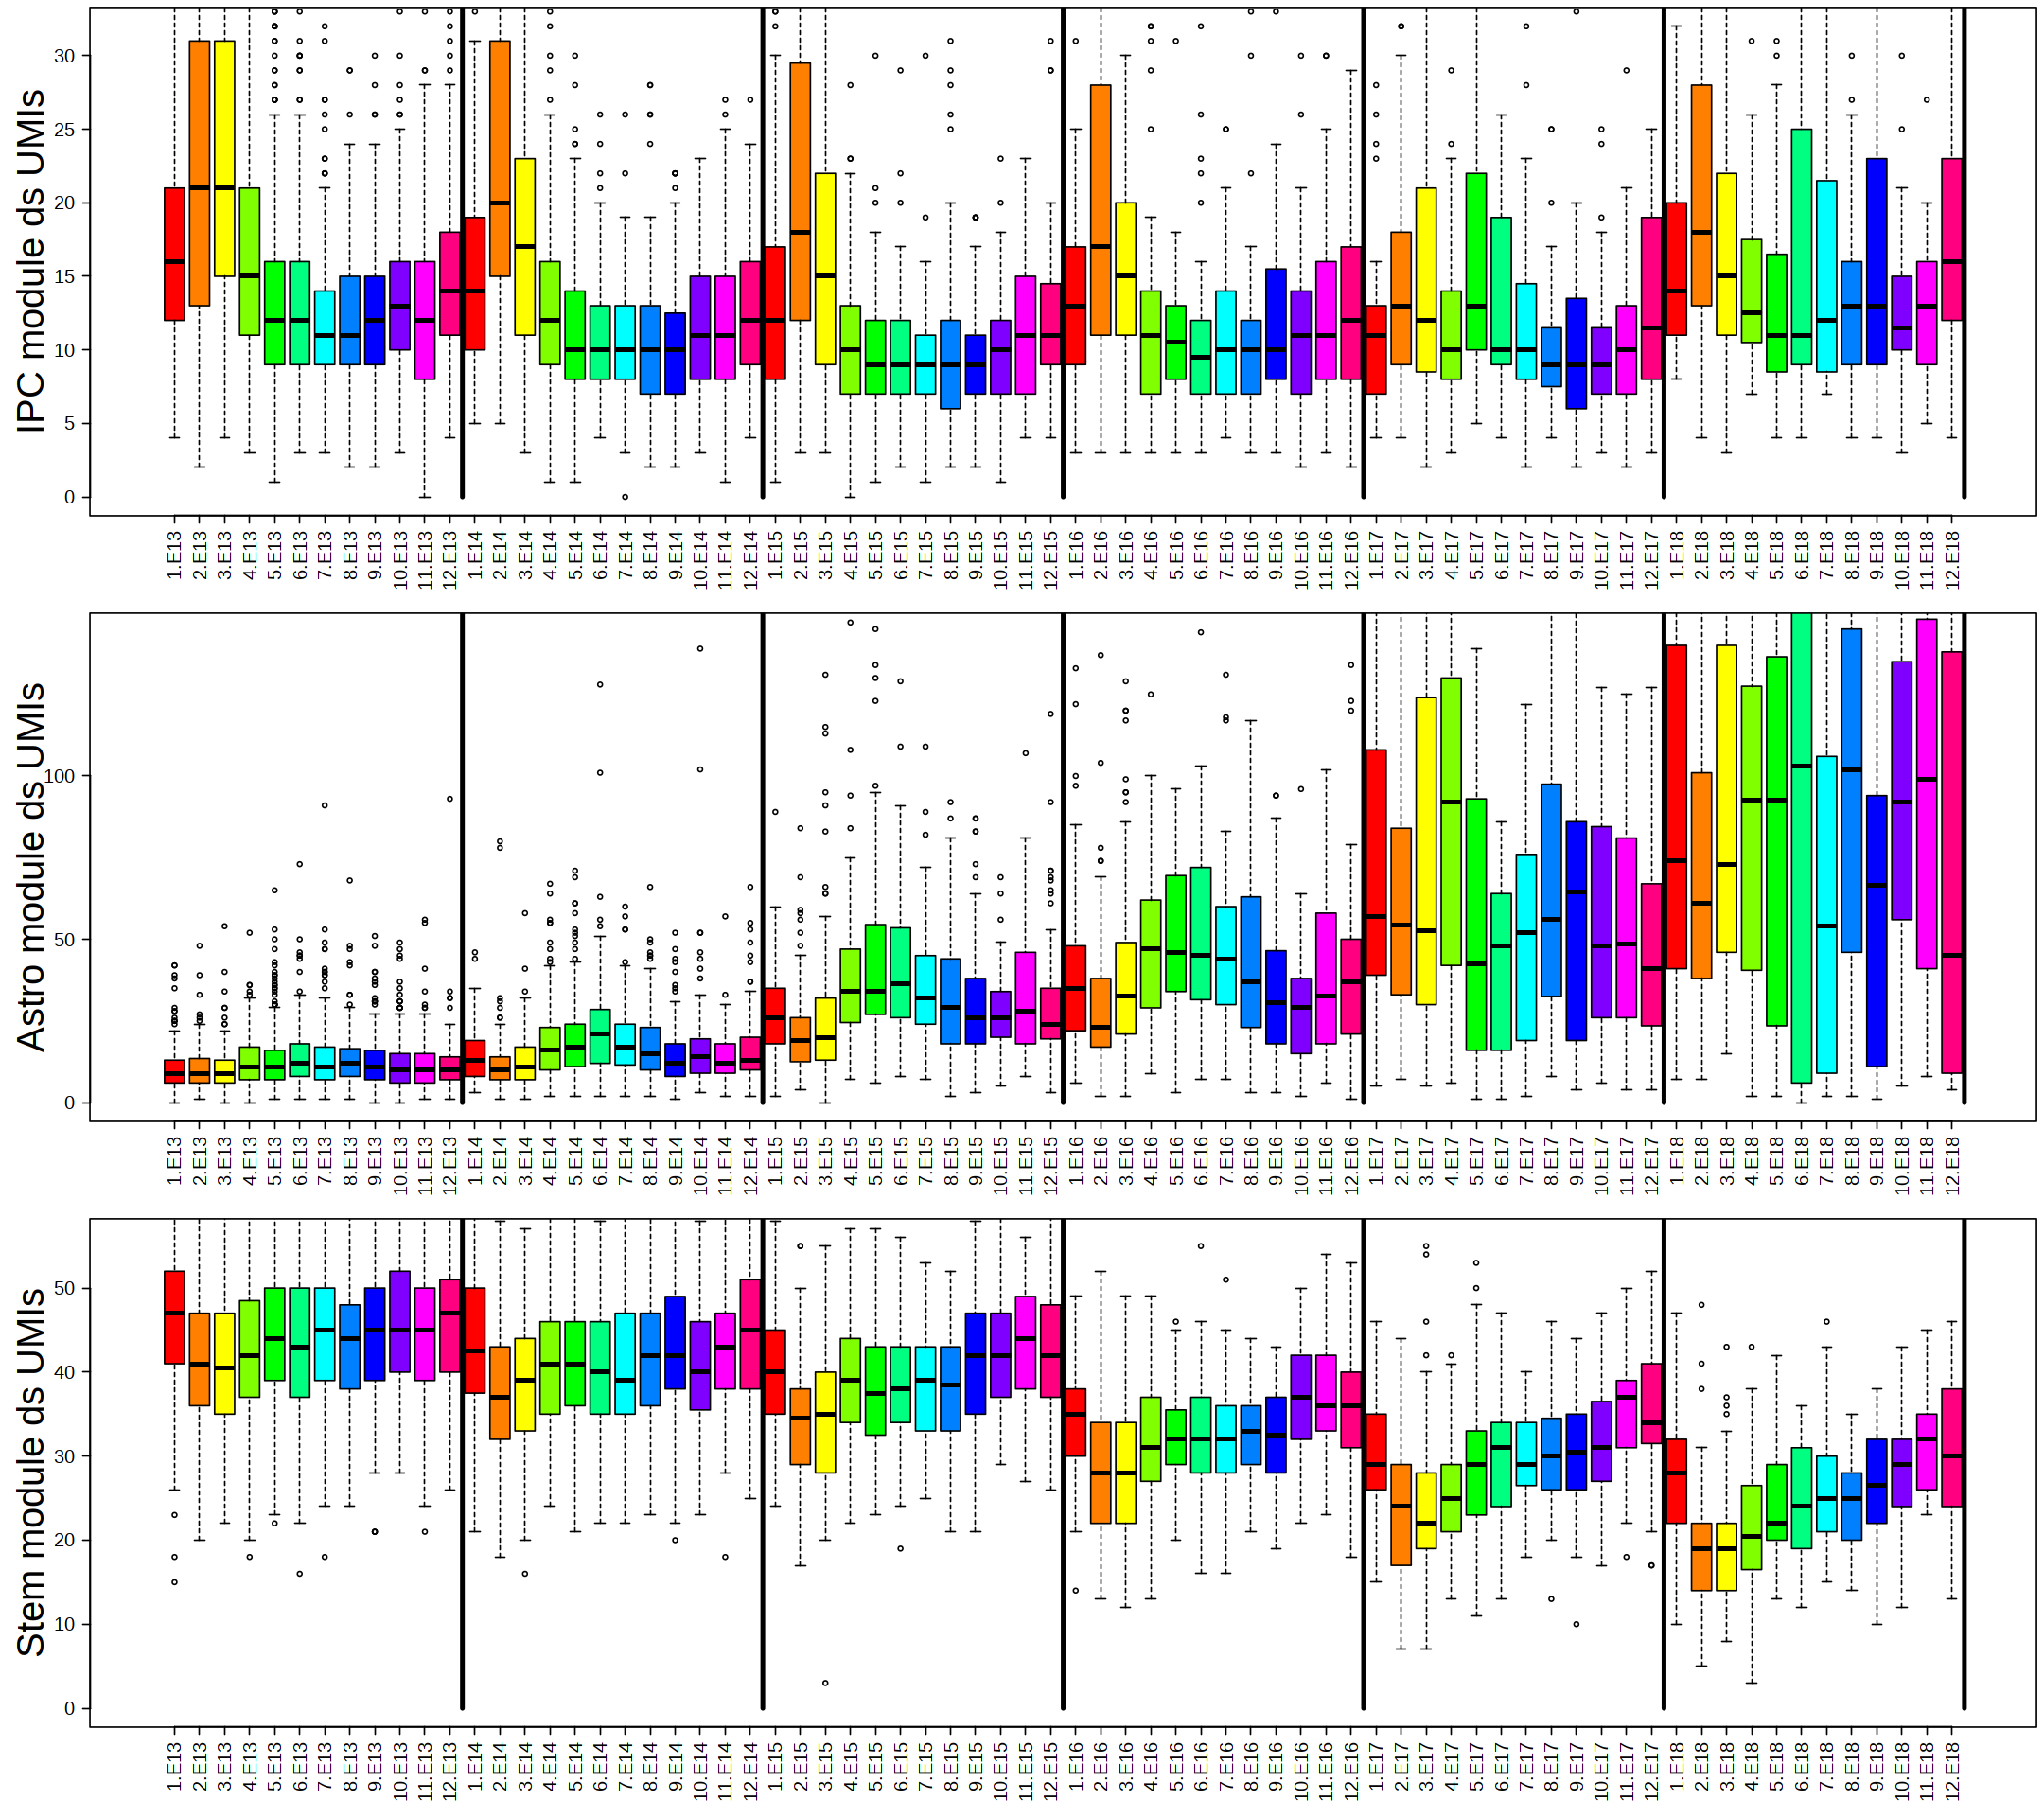

In [98]:
options(repr.plot.width = 18)
options(repr.plot.height = 16)

nsc_inds <- which(sc_data_df$cell_type == 'NSC')
lupc <- length(unique(phase_cut))
bin_seq <- seq(lupc+0.5, 0.5+length(days)*lupc, 12)
png('./output/metacell_model/nsc_gene_modules/figs/modules_in_nsc_scs_by_day_and_phase.png', h = 1050, w = 1600)
par(mfrow = c(3,1), las = 2, cex.lab = 3, cex.axis = 1.5, mar = c(6,6,0.5,0.5))
boxplot(ipc ~ ., data = sc_data_df[nsc_inds,c('ipc','phase_cut', 'day')], ylim = c(0,quantile(sc_data_df$ipc[nsc_inds], 0.94, na.rm = T)),
       col = rep(rainbow(lupc), length(days)), ylab = 'IPC module ds UMIs', xlab = '')
vvv <- sapply(bin_seq, function(i) lines(rep(i,2), c(0,1000), lwd = 3))
boxplot(astro ~ ., data = sc_data_df[nsc_inds,c('astro','phase_cut', 'day')], ylim = c(0,quantile(sc_data_df$astro[nsc_inds], 0.975, na.rm = T)),
              col = rep(rainbow(lupc), length(days)), ylab = 'Astro module ds UMIs', xlab = '')
vvv <- sapply(bin_seq, function(i) lines(rep(i,2), c(0,1000), lwd = 3))
boxplot(stem ~ ., data = sc_data_df[nsc_inds,c('stem','phase_cut', 'day')], ylim = c(0,quantile(sc_data_df$stem[nsc_inds], 0.95, na.rm = T)),
              col = rep(rainbow(lupc), length(days)), ylab = 'Stem module ds UMIs', xlab = '')
vvv <- sapply(bin_seq, function(i) lines(rep(i,2), c(0,1000), lwd = 3))
# boxplot(cc ~ ., data = sc_data_df[nsc_inds,c('cc','phase_cut', 'day')], ylim = c(0,quantile(sc_data_df$cc[nsc_inds], 0.95, na.rm = T)),
#               col = rep(c('red', 'orange', 'yellow', 'green', 'blue1', 'blue4', 'purple3'), 6), ylab = 'C.C. module ds UMIs', xlab = '')
# vvv <- sapply(seq(7.5,49.5,7), function(i) lines(rep(i,2), c(0,1000), lwd = 3))
dev.off()

In [115]:
comparison_table <- cbind(c('2_S', '4_M', '5_G0'), c('4_M', '5_G0', '2_S'))
comparison_table

nsc_ipc_bias_ks_res <- apply(comparison_table, 1, function(x) {
    sapply(names(nsc_sc_by_day), function(di) {
    suppressWarnings(ks.test(sc_data_df[intersect(names(pba)[pba == x[[1]]], nsc_sc_by_day[[di]]),'ipc'],
            sc_data_df[intersect(names(pba)[pba == x[[2]]], nsc_sc_by_day[[di]]),'ipc'])$p.value)
    })})

colnames(nsc_ipc_bias_ks_res) <- apply(comparison_table,1, paste0, collapse = '-')

nsc_astro_bias_ks_res <- apply(comparison_table, 1, function(x) {
    sapply(names(nsc_sc_by_day), function(di) {
    suppressWarnings(ks.test(sc_data_df[intersect(names(pba)[pba == x[[1]]], nsc_sc_by_day[[di]]),'astro'],
            sc_data_df[intersect(names(pba)[pba == x[[2]]], nsc_sc_by_day[[di]]),'astro'])$p.value)
})})

colnames(nsc_astro_bias_ks_res) <- apply(comparison_table,1, paste0, collapse = '-')

cn <- colnames(nsc_ipc_bias_ks_res)
rn <- rownames(nsc_ipc_bias_ks_res)

nsc_ipc_bias_ks_res <- matrix(p.adjust(nsc_ipc_bias_ks_res, method = 'BH'), nrow = nrow(nsc_ipc_bias_ks_res), ncol = ncol(nsc_ipc_bias_ks_res), dimnames = list(rn, cn))

nsc_astro_bias_ks_res <- matrix(p.adjust(nsc_astro_bias_ks_res, method = 'BH'), nrow = nrow(nsc_astro_bias_ks_res), ncol = ncol(nsc_astro_bias_ks_res), dimnames = list(rn, cn))

nsc_ipc_bias_ks_res

nsc_astro_bias_ks_res

get_num_asterisks <- function(pv_vec) {
    powvec <- 5*10**seq(-4,0,1)
    npi <- 4 - sapply(pv_vec, function(x) which.max(powvec > x))
    npi <- ifelse(npi < 1, 0, npi)
    npi <- ifelse(npi > 3, 3, npi)
    return(npi)
                                      }

plot_asterisks <- function(x, y, npi) {
    xl <- sapply(seq_along(npi), function(i) {
        if (npi[[i]] > 1) {
            return(seq(x[[i]] - 0.1*npi[[i]], x[[i]] + 0.1*npi[[i]], l = npi[[i]]))
        } else if (npi[[i]] == 1) {return(x[[i]])}
    })
    points(unlist(xl), rep(y, length(unlist(xl))), pch = 8, cex = 6, col = 'red', lwd= 5)
}

npi_ipc <- apply(nsc_ipc_bias_ks_res, 2, get_num_asterisks)

npi_astro <- apply(nsc_astro_bias_ks_res, 2, get_num_asterisks)

2_S,4_M
4_M,5_G0
5_G0,2_S


,2_S-4_M,4_M-5_G0,5_G0-2_S
13,0.189411610,0.000000e+00,0.000000e+00
14,0.110879759,0.000000e+00,0.000000e+00
15,0.411326506,9.381984e-08,0.000000e+00
16,0.289768821,1.058431e-03,1.519884e-11
17,0.006256145,1.599896e-04,5.841517e-01
18,0.189411610,1.019122e-03,1.502423e-05


,2_S-4_M,4_M-5_G0,5_G0-2_S
13,2.706343e-02,0.115349339,1.474459e-05
14,1.243724e-06,0.011109344,0.000000e+00
15,1.825433e-04,0.001287233,0.000000e+00
16,1.127491e-04,0.840514058,1.243724e-06
17,2.385089e-01,0.054321679,1.110934e-02
18,1.105772e-01,0.003405177,4.052004e-03


In [104]:
source('scripts/util.r')

In [116]:
options(repr.plot.width = 16)
options(repr.plot.height = 8)

eg <- expand.grid(days, c('S', 'M','G1_0'))
bin_names <- gsub('^\\d_', '', apply(eg[order(eg[,1]),], 1, paste0, collapse = '\n'))
inds_plot <- seq(1,length(days)*4,4)
inds_plot <- sort(c(inds_plot, inds_plot+1, inds_plot+2))
png(glue::glue('./output/metacell_model/nsc_gene_modules/figs/s_vs_m_ipc_and_astro_dsumis_in_nsc_boxplots_test.png'), h = 3000, w = 3000)
par(mfrow = c(2,1), mar = c(10,10,7,1), cex.main = 5, cex.axis = 4, col.main = col_key[['IPC']], cex.lab = 4)
plot(0, xlim = c(0.5,23.5), ylim = c(0, quantile(sc_data_df$ipc[sc_data_df$cell_type == 'NSC'], 0.975, na.rm = T)), 
     xaxt = 'n', xlab = '', main = 'IPC module expression in NSC by phase across time', ylab = '')
ttt <- lapply(sort(unique(sc_data_df$day)), function(di) {
    ind <- match(di, sort(unique(sc_data_df$day)))
    boxplot(ipc ~ pba, data = dplyr::select(dplyr::filter(sc_data_df[nsc_sc,], pba %in% c('2_S', '4_M', '5_G0'), day == di), ipc, pba), lwd = 6,
            at = inds_plot[c(3*ind -2, 3*ind-1, 3*ind)], add = T, xaxt = 'n', xlab = '', col = rep(phase_color_key[c('2_S', '4_M', '5_G0')], 6))
})
axis(1, at = inds_plot, labels = bin_names, line = 5, tick = F, lwd = 5)
title(ylab = 'IPC module downsampled UMIs', line = 5)
for (ind in 1:6) {
    lines(inds_plot[c(3*ind -2, 3*ind-1)], rep(30,2), lwd = 3.5, col = 'red')
    plot_asterisks(x = inds_plot[3*ind]-1.5, y = 32, npi = npi_ipc[ind,1])
    lines(inds_plot[c(3*ind-1, 3*ind)], rep(32,2), lwd = 3.5, col = 'red')
    plot_asterisks(x = inds_plot[3*ind]-0.5, y = 34, npi = npi_ipc[ind,2])
    lines(inds_plot[c(3*ind-2, 3*ind)], rep(36,2), lwd = 3.5, col = 'red')
    plot_asterisks(x = inds_plot[3*ind]-1, y = 38, npi = npi_ipc[ind,3])
}
par(col.main = col_key[['Astrocytes']])
plot(0, xlim = c(0.5,23.5), ylim = c(0, quantile(sc_data_df$astro[sc_data_df$cell_type == 'NSC'], 0.995, na.rm = T)), 
     xaxt = 'n', xlab = '', main = 'Astro module expression in NSC by phase across time', ylab = '')
ttt <- lapply(sort(unique(sc_data_df$day)), function(di) {
    ind <- match(di, sort(unique(sc_data_df$day)))
    boxplot(astro ~ pba, data = dplyr::select(dplyr::filter(sc_data_df[nsc_sc,], pba %in% c('2_S', '4_M', '5_G0'), day == di), astro, pba), lwd = 6,
            at = inds_plot[c(3*ind -2, 3*ind-1, 3*ind)], add = T, xaxt = 'n', xlab = '', col = rep(phase_color_key[c('2_S', '4_M', '5_G0')], 6))
})
axis(1, at = inds_plot, labels = bin_names, line = 5, tick = F, lwd = 5)
title(ylab = 'Astro module downsampled UMIs', line = 5)
for (ind in 1:6) {
    lines(inds_plot[c(3*ind -2, 3*ind-1)], rep(160,2), lwd = 3.5, col = 'red')
    plot_asterisks(x = inds_plot[3*ind]-1.5, y = 166, npi = npi_astro[ind,1])
    lines(inds_plot[c(3*ind-1, 3*ind)], rep(168,2), lwd = 3.5, col = 'red')
    plot_asterisks(x = inds_plot[3*ind]-0.5, y = 174, npi = npi_astro[ind,2])
    lines(inds_plot[c(3*ind-2, 3*ind)], rep(180,2), lwd = 3.5, col = 'red')
    plot_asterisks(x = inds_plot[3*ind]-1, y = 186, npi = npi_astro[ind,3])
}
title(ylab = 'Astro module downsampled UMIs', line = 5)
dev.off()

png 
  2

### Make sure NSCs don't express IPC_cyc markers, and vice-versa

In [118]:
indsh <- rownames(sc_data_df)[sc_data_df$cell_type %in% c('NSC', 'IPC', 'IPC_cyc')]
# xl_nsc <- quantile(sc_data_df[indsh,'nsc'], c(0,1))
# xl_ipc <- quantile(sc_data_df[indsh,'ipc'], c(0,1))
# xl_stem <- quantile(sc_data_df[indsh,'stem'], c(0,1))
# xl_pr <- quantile(sc_data_df[indsh,'phase_rev'], c(0,1))


In [119]:
pcu_nsc_ipc <- principal_curve(as.matrix(sc_data_df[indsh,c('ipc', 'nsc')]))

In [120]:
cells_astro_nsc <- rownames(sc_data_df)[sc_data_df$cell_type %in% c('Astrocytes', 'NSC')]
cells_astro_ss_nsc <- rownames(sc_data_df)[union(which(sc_data_df$cell_type == 'Astrocytes'), 
                                                 sample(x = which(sc_data_df$cell_type == 'NSC'), size = length(which(sc_data_df$cell_type == 'Astrocytes'))))]
cells_astro_nsc_f <- setdiff(cells_astro_nsc, rownames(sc_data_df)[sc_data_df$ipc >= 30])
indsh_f <- setdiff(indsh, rownames(sc_data_df)[sc_data_df$astro >= 30])
# cells_astro_nsc_hi_astro <- cells_astro_nsc[which(sc_data_df[cells_astro_nsc,'astro'] >= 25)]

In [121]:
pcu_nsc_astro <- principal_curve(as.matrix(sc_data_df[cells_astro_ss_nsc,c('astro', 'nsc')]))

ord_pcu_nsc_astro <- order(apply(sc_data_df[cells_astro_ss_nsc,c('astro', 'nsc')], 1, diff), decreasing = T)

In [122]:
match_points_to_pcu <- function(x, pcu, frac_subsample = 0.1) {
    pcu <- pcu[order(pcu[,1]),]
    phase_pcu_rm_ss <- pcu[sort(sample(x = nrow(pcu), size = round(nrow(pcu)*frac_subsample), replace = F)),]
    dist_phase_pc_to_pcu <- as.matrix(tgstat::tgs_dist(rbind(x[,1:2], phase_pcu_rm_ss[,1:2])))
    rownames(dist_phase_pc_to_pcu) <- c(rownames(dist_phase_pc_to_pcu)[1:nrow(x)], paste0('p', 1:nrow(phase_pcu_rm_ss)))
    colnames(dist_phase_pc_to_pcu) <- c(colnames(dist_phase_pc_to_pcu)[1:nrow(x)], paste0('p', 1:nrow(phase_pcu_rm_ss)))
    knn_phase_pc_to_pcu <- tgstat::tgs_knn(1/dist_phase_pc_to_pcu[(nrow(x)+1):ncol(dist_phase_pc_to_pcu),1:nrow(x)], k = 1)
    rownames(dist_phase_pc_to_pcu)[(nrow(cc_mat_rot)+1):ncol(dist_phase_pc_to_pcu)]
    knn_phase_pc_to_pcu[,2] <- paste0('p', 1:nrow(phase_pcu_rm_ss))[match(knn_phase_pc_to_pcu[,2], rownames(dist_phase_pc_to_pcu))]
    matched_points <- setNames(as.numeric(gsub('^p', '', knn_phase_pc_to_pcu[,2]))[match(rownames(x), as.character(knn_phase_pc_to_pcu[,1]))],
                      rownames(x))
    return(matched_points)
}

In [123]:
matched_coords <- match_points_to_pcu(as.matrix(sc_data_df[indsh_f,c('ipc', 'nsc')]), pcu_nsc_ipc$s, frac_subsample = 0.1)

In [124]:
matched_coords_bins <- setNames(cut(matched_coords, breaks = round(seq(0, max(matched_coords), l = 20))), names(matched_coords))

In [125]:
matched_coords_astro <- match_points_to_pcu(as.matrix(sc_data_df[cells_astro_nsc_f,c('astro', 'nsc')]), pcu_nsc_astro$s[order(pcu_nsc_astro$s[,1]),], frac_subsample = 1)

In [126]:
matched_coords_bins_astro <- setNames(cut(matched_coords_astro, breaks = round(seq(0, max(matched_coords_astro), l = 20))), names(matched_coords_astro))

In [127]:

cti_inds <- which(names(matched_coords_bins) %in% names(mc@mc[mc@mc %in% which(mcmd$cell_type %in% c('NSC', 'IPC', 'IPC_cyc'))]))
tbl_phase_by_nsc_ipc_axis <- table(matched_coords_bins[cti_inds], sc_data_df[names(matched_coords_bins)[cti_inds],'pba'])
mat_phase_by_nsc_ipc_axis <- as.matrix(t(tbl_phase_by_nsc_ipc_axis))
mat_phase_norm <- t(t(mat_phase_by_nsc_ipc_axis)/colSums(mat_phase_by_nsc_ipc_axis))

colnames(mat_phase_norm) <- 1:ncol(mat_phase_norm)
colnames(mat_phase_by_nsc_ipc_axis) <- 1:ncol(mat_phase_by_nsc_ipc_axis)

tbl_ct_by_princurve_bin <- table(matched_coords_bins[cti_inds], sc_data_df[names(matched_coords_bins)[cti_inds],'cell_type'])

mat_ct_by_princurve_bin <- t(as.matrix(tbl_ct_by_princurve_bin))
mat_ct_by_princurve_bin_norm <- t(t(mat_ct_by_princurve_bin)/colSums(mat_ct_by_princurve_bin))
colnames(mat_ct_by_princurve_bin_norm) <- 1:ncol(mat_ct_by_princurve_bin_norm)
colnames(mat_ct_by_princurve_bin) <- 1:ncol(mat_ct_by_princurve_bin)

In [128]:

# cti_inds <- which(names(matched_coords_bins_astro) %in% names(mc@mc[mc@mc %in% which(mcmd$cell_type %in% c('NSC', 'A'))]))
tbl_phase_by_nsc_astro_axis <- table(matched_coords_bins_astro, sc_data_df[names(matched_coords_bins_astro),'pba'])
mat_phase_by_nsc_astro_axis <- as.matrix(t(tbl_phase_by_nsc_astro_axis))
mat_phase_astro_norm <- t(t(mat_phase_by_nsc_astro_axis)/colSums(mat_phase_by_nsc_astro_axis))

colnames(mat_phase_astro_norm) <- 1:ncol(mat_phase_astro_norm)
colnames(mat_phase_by_nsc_astro_axis) <- 1:ncol(mat_phase_by_nsc_astro_axis)

tbl_ct_by_princurve_bin_astro <- table(matched_coords_bins_astro, sc_data_df[names(matched_coords_bins_astro),'cell_type'])

mat_ct_by_princurve_bin_astro <- t(as.matrix(tbl_ct_by_princurve_bin_astro))
mat_ct_by_princurve_bin_astro_norm <- t(t(mat_ct_by_princurve_bin_astro)/colSums(mat_ct_by_princurve_bin_astro))
colnames(mat_ct_by_princurve_bin_astro_norm) <- 1:ncol(mat_ct_by_princurve_bin_astro_norm)
colnames(mat_ct_by_princurve_bin_astro) <- 1:ncol(mat_ct_by_princurve_bin_astro)

## Fig S2H, S2I

In [135]:
### Plot IPC vs stem and astro vs stem signatures
options(repr.plot.width = 10)
options(repr.plot.height = 5)
png('./output/metacell_model/nsc_gene_modules/figs/ipc_and_astro_vs_stem_module_umis.png', w = 800, h = 400, res = 100)
par(mfrow = c(1,2), mar = c(5,5,1,1), cex.lab = 1, cex.axis = 1)
plot(sc_data_df[names(matched_coords_bins),'ipc'], sc_data_df[names(matched_coords_bins),'stem'], col = mcmd$color[mc@mc[names(matched_coords_bins)]], ylab = 'Stem module UMIs', xlab = 'IPC module UMIs', pch =16, cex = 0.5)
plot(sc_data_df[names(matched_coords_bins_astro),'astro'], sc_data_df[names(matched_coords_bins_astro),'stem'], col = mcmd$color[mc@mc[names(matched_coords_bins_astro)]], ylab = 'Stem module UMIs', xlab = 'Astro module UMIs', pch =16, cex = 0.5)
dev.off()

png 
  2

## Fig 2F

In [129]:
options(repr.plot.width = 10)
options(repr.plot.height = 10)
# png(glue::glue('./output/metacell_model/nsc_gene_modules/figs/phase_probs_by_astro_and_ipc_axes_princurve_bin_barplots.png'), h = 800, w = 700)
pdf(glue::glue('./output/metacell_model/nsc_gene_modules/figs/phase_probs_by_astro_and_ipc_axes_princurve_bin_barplots.pdf'), h = 8, w = 7)
par(mar = c(4,3,3,2), cex.main = 1.5, cex.axis = 1.5)
nf <- graphics::layout(mat = matrix(c(1, 2, 2, 3, 3, 4, 5, 6, 6, 7, 7, 8), nrow = 6, ncol = 2))

# row 1, col 1
plot(log2((1+mat_phase_by_nsc_ipc_axis['2_S',])/(1+mat_phase_by_nsc_ipc_axis['4_M',])), main = 'log2 S/M fraction ratio - IPC-NSC axis', type= 'l', ylab = '')
lines(c(-10,30), c(0,0), col = 'red', lty = 2, lwd = 2)

# row 2, col 1
barplot(mat_phase_norm[c(5,1:4),], col = phase_color_key[c(5,1:4)], ylab = '', main = 'Phase fractions by IPC-NSC princurve bin', add = F)

# row 3, col 1
barplot(mat_ct_by_princurve_bin_norm, col = col_key[rownames(mat_ct_by_princurve_bin_norm)], ylab = '', main = 'Cell type fractions by IPC-NSC princurve bin', add = F)

# row 4, col 1
yh <- log2(colSums(mat_phase_by_nsc_ipc_axis[2:4,])/colSums(mat_phase_by_nsc_ipc_axis[c(1,5),])) 
plot(yh, main = 'log2 cycling/non-cycling ratio - IPC-NSC axis', , type = 'l', xlab = '')
lines(c(-10,30), c(0,0), col = 'red', lty = 2, lwd = 2)

# row 1, col 2
par(mar = c(4,3,3,2), cex.main = 1.5, cex.axis = 1.5)
plot(log2((1+mat_phase_by_nsc_astro_axis['2_S',])/(1+mat_phase_by_nsc_astro_axis['4_M',])), main = 'log2 S/M fraction ratio - astro-NSC axis', type= 'l', ylab = '')
lines(c(-10,30), c(0,0), col = 'red', lty = 2, lwd = 2)

# row 2, col 2
barplot(mat_phase_astro_norm[c(5,1:4),], col = phase_color_key[c(5,1:4)], ylab = '', main = 'Phase fractions by Astro-NSC princurve bin', add = F)
# legend(x = 23,y = 1, legend = names(phase_color_key), col = phase_color_key, pch = 15, cex = 1.5, xpd = T)

# row 3, col 2
barplot(mat_ct_by_princurve_bin_astro_norm, col = col_key[rownames(mat_ct_by_princurve_bin_astro_norm)], ylab = '', main = 'Cell type fractions by Astro-NSC princurve bin', add = F)

# row 4, col 2
yh <- log2(colSums(mat_phase_by_nsc_astro_axis[2:4,])/colSums(mat_phase_by_nsc_astro_axis[c(1,5),])) 
plot(yh, main = 'log2 cycling/non-cycling ratio - astro-NSC axis', ylim = max(abs(yh))*c(-1,1), type = 'l', xlab = '')
lines(c(-10,30), c(0,0), col = 'red', lty = 2, lwd = 2)


dev.off()

png 
  2

## Fig S2A

In [46]:
dir.create('./output/metacell_model/figs/nsc_gene_module_analysis')
dir.create('./output/metacell_model/figs/nsc_gene_module_analysis/pheatmaps')
dir.create('./output/metacell_model/figs/nsc_gene_module_analysis/boxplots')


vvv <- lapply(sort(unique(ct_hc_cor_nsc)), function(clj) {
    gnj <- names(ct_hc_cor_nsc)[ct_hc_cor_nsc == clj]
    # png(glue::glue('./output/metacell_model/figs/nsc_gene_module_analysis/boxplots/cluster_{clj}.png'), h = 600, w = 800)
    par(las = 2, cex.main = 2, cex.lab = 3,cex.axis = 2,mar = c(14,4,4,0.5))
    boxplot(st_legc[gnj,cust_st_ord2], col = col_key[cust_st_ord2], main = paste('Cluster', clj))
    # dev.off()
})

clrmp_rna <- colorRampPalette(c('white', 'orange', 'red','purple', 'black'))(100)
clrmp_rel <- colorRampPalette(c('blue3', 'white', 'red3'))(100)

options(repr.plot.height = 8)
options(repr.plot.width = 16)

vvv <- lapply(sort(unique(ct_hc_cor_nsc)), function(clj) {
    gnj <- names(ct_hc_cor_nsc)[ct_hc_cor_nsc == clj]
    pltmtj <- legc[gnj,cust_mc_ord_st2] - rowMeans(legc[gnj,nsc_mcs])
    p_clj <- pheatmap::pheatmap(pltmtj, color = clrmp_rel, treeheight_row = 0, fontsize_row = 8, show_colnames = F,
                       # breaks = seq(-16.6,-8,l=100), 
                       breaks = seq(-3,3,l=100), 
                       annotation_col = col_annot, annotation_colors = ann_colors, cluster_cols = F, silent = T)
    # save_pheatmap_png(p_clj, glue::glue('./output/metacell_model/figs/nsc_gene_module_analysis/pheatmaps/cluster_{clj}.png'), h = 16*nrow(pltmtj), w = 2000)
})